# Importing the libraries

We can see that we have a dictionary which contains key of test, validation and training.

In [ ]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "

In [ ]:
!pip install nltk

In [ ]:
!pip install wordninja

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541530 sha256=bf76fc7e068a533c9b4b251858879e4da5466c879d696d0530f00b83558e8be1
  Stored in directory: /root/.cache/pip/wheels/e6/66/9c/712044a983337f5d44f90abcd244bd4b8ad28ee64750404b50
Successfully built wordninja


In [ ]:
#importing necessary libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
import numpy as np
from nltk import pos_tag
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import plotly.graph_objects as go
import plotly.express as px
import wordninja

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
try:
    nltk.data.find('corpora/words')
except LookupError:
    nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


# **DATASET EXPLORATION**

## Downloading the dataset

In [ ]:
# Load the RACE dataset, specifying the desired configuration
dataset_complete = load_dataset("ehovy/race", "all") # Choose 'all', 'high', or 'middle'
dataset_high = load_dataset("ehovy/race", "high") # Choose 'all', 'high', or 'middle'
dataset_middle = load_dataset("ehovy/race", "middle") # Choose 'all', 'high', or 'middle

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

...

train-00000-of-00001.parquet:   0%|          | 0.00/6.97M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/407k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1436 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/25421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1436 [00:00<?, ? examples/s]

Print the keys of this dataset to see what were the subdivision given by the creator of this dataset.

In [ ]:
# Check available splits
print(dataset_complete.keys())

dict_keys(['test', 'train', 'validation'])


Print the dataset to have a better understanding of what we are dealing with.

In [ ]:
dataset_complete

DatasetDict({
    test: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4934
    })
    train: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 87866
    })
    validation: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4887
    })
})

Analyze what percentage of the dataset was dedicated to the training what part of the dataset was dedicated to the training, what part to the test and what part to the validation. After running the following cell we can see that more or less we have the same kind of split of approximately 90% for training dataset and 5% for both validation and test dataset

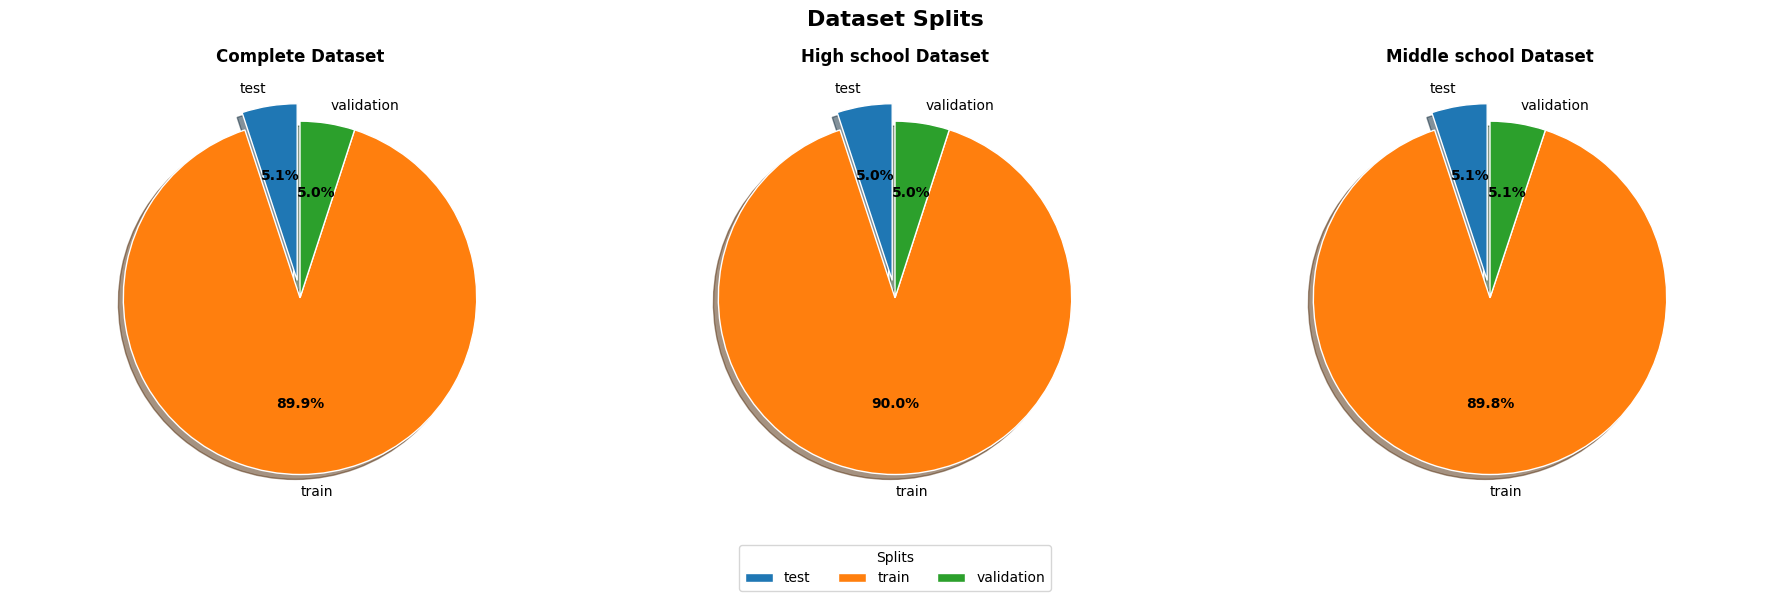

In [ ]:
def visualize_data_split(dataset, ax, title="Dataset Split Distribution", explode_index=0):
    """
    Create a pie chart visualizing the distribution of dataset splits on a given axis.

    Parameters:
    -----------
    dataset : dict
        Dictionary containing the dataset splits.
    ax : matplotlib.axes.Axes
        The axes to draw the pie chart on.
    title : str, optional
        Title of the pie chart.
    explode_index : int, optional
        Index of the split to be 'exploded' in the pie chart.
    """
    # Calculate the percentage of each split
    total_examples = sum(len(dataset[split]) for split in dataset)
    percentages = {split: (len(dataset[split]) / total_examples) * 100 for split in dataset}

    # Create the pie chart
    labels = list(percentages.keys())
    sizes = list(percentages.values())

    # Create explode tuple with the specified index exploded
    explode = [0] * len(labels)
    if 0 <= explode_index < len(labels):
        explode[explode_index] = 0.1

    # Generate the pie chart with improved visuals
    wedges, texts, autotexts = ax.pie(
        sizes,
        explode=explode,
        labels=labels,
        autopct='%1.1f%%',
        shadow=True,
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax.axis('equal')

    # Set title with improved styling
    ax.set_title(title, fontsize=12, fontweight='bold')

    # Enhance the appearance of the percentage text
    for autotext in autotexts:
        autotext.set_fontweight('bold')

    return wedges, labels

# Create a single figure with three subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Call the function with each dataset on a different subplot
wedges1, labels1 = visualize_data_split(dataset_complete, axes[0], title="Complete Dataset")
wedges2, labels2 = visualize_data_split(dataset_high, axes[1], title="High school Dataset")
wedges3, labels3 = visualize_data_split(dataset_middle, axes[2], title="Middle school Dataset")

# Add a common legend for all charts
fig.legend(wedges1, labels1, title="Splits", loc="lower center", ncol=len(labels1), bbox_to_anchor=(0.5, 0))

# Add a main title for the figure
fig.suptitle("Dataset Splits", fontsize=16, fontweight='bold', y=0.98)

# Adjust layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Show the combined figure
plt.show()

We can even check first few rows of train dataset:

In [ ]:
for i in range(4):
  print(dataset_complete['train'][i])

{'example_id': 'high19088.txt', 'article': 'Last week I talked with some of my students about what they wanted to do after they graduated, and what kind of job prospects  they thought they had.\nGiven that I teach students who are training to be doctors, I was surprised do find that most thought that they would not be able to get the jobs they wanted without "outside help". "What kind of help is that?" I asked, expecting them to tell me that they would need a   or family friend to help them out.\n"Surgery ," one replied.\nI was pretty alarmed by that response. It seems that the graduates of today are increasingly willing to go under the knife to get ahead of others when it comes to getting a job .\nOne girl told me that she was considering surgery to increase her height. "They break your legs, put in special extending screws, and slowly expand the gap between the two ends of the bone as it re-grows, you can get at least 5 cm taller!"\nAt that point, I was shocked. I am short, I can\'t 

We can see that from the previous cell that each row reppresent a question related to an article. Since there are multiple questions for each article the "article" cell gets repeated for each question. we will deal with that in the section of dataset manipulation

In [ ]:
print(f"Number of articles in dataset_high: {len(dataset_high['train']) + len(dataset_high['validation']) + len(dataset_high['test'])}")
print(f"Number of articles in dataset_middle: {len(dataset_middle['train']) + len(dataset_middle['validation']) + len(dataset_middle['test'])}")

Number of articles in dataset_high: 69394
Number of articles in dataset_middle: 28293


## Sanity check
I would love to make sure that in the split that were proposed by the creator of this dataset there were no overlap of article (meaning an article on the training set should not be repeated on the test set). Next cell tackle this concern

In [ ]:
def check_article_overlaps(dataset):
  # Create a set to store unique articles in each split
  train_articles = set()
  validation_articles = set()
  test_articles = set()

  # Iterate through the training split and add articles to the train_articles set
  for example in dataset['train']:
      train_articles.add(example['article'])

  # Iterate through the validation split and add articles to the validation_articles set
  for example in dataset['validation']:
      validation_articles.add(example['article'])

  # Iterate through the test split and add articles to the test_articles set
  for example in dataset['test']:
      test_articles.add(example['article'])

  # Check for overlapping articles between train and validation
  train_validation_overlap = train_articles.intersection(validation_articles)
  print(f"Number of overlapping articles between train and validation: {len(train_validation_overlap)}")

  # Check for overlapping articles between train and test
  train_test_overlap = train_articles.intersection(test_articles)
  print(f"Number of overlapping articles between train and test: {len(train_test_overlap)}")

  # Check for overlapping articles between validation and test
  validation_test_overlap = validation_articles.intersection(test_articles)
  print(f"Number of overlapping articles between validation and test: {len(validation_test_overlap)}")

print("Overlaps with complete dataset:")
check_article_overlaps(dataset_complete)
print("\n\nOverlaps with high school dataset:")
check_article_overlaps(dataset_high)
print("\n\nOverlaps with middle school dataset:")
check_article_overlaps(dataset_middle)

Overlaps with complete dataset:
Number of overlapping articles between train and validation: 0
Number of overlapping articles between train and test: 0
Number of overlapping articles between validation and test: 0


Overlaps with high school dataset:
Number of overlapping articles between train and validation: 0
Number of overlapping articles between train and test: 0
Number of overlapping articles between validation and test: 0


Overlaps with middle school dataset:
Number of overlapping articles between train and validation: 0
Number of overlapping articles between train and test: 0
Number of overlapping articles between validation and test: 0


## Dataset Manipulation

**Observation**: The original dataset contained many duplicated articles, with each question linked to its corresponding article in the table. To improve efficiency, we decided to compress the dataset by keeping each article only once and nesting all related questions within it.

This version is more direct and easier to understand while preserving the original meaning.

First i will recostruct the data using multiple dictionaries containing each an id of the article as key and inside it the text of the article with in it also the text of the article and the list of questions and answers.

In [ ]:
def create_article_mapping(dataset_complete):
    """Create a consistent article to ID mapping for the complete dataset"""
    article_to_id = {}
    for split in ['train', 'validation', 'test']:
      for example in dataset_complete[split]:
          article = example['article']
          if article not in article_to_id:
              article_to_id[article] = len(article_to_id)
    return article_to_id

In [ ]:
def restructure_dataset_with_mapping(dataset, article_to_id):
    """
    Restructures dataset using pre-defined article IDs
    Returns dictionary with article_id as keys
    """
    restructured = {}

    for example in dataset:
        article = example['article']
        article_id = article_to_id[article]

        question_info = {
            'example_id': example['example_id'],
            'question': example['question'],
            'options': example['options'],
            'answer': example['answer']
        }

        if article_id not in restructured:
            restructured[article_id] = {
                'article_text': article,
                'questions': []
            }

        restructured[article_id]['questions'].append(question_info)

    return restructured

In [ ]:
# First create the unified mapping using the complete dataset
article_to_id = create_article_mapping(dataset_complete)

# Then restructure all datasets using the same mapping
middle_train_dict = restructure_dataset_with_mapping(dataset_middle['train'], article_to_id)
high_train_dict = restructure_dataset_with_mapping(dataset_high['train'], article_to_id)
complete_train_dic = restructure_dataset_with_mapping(dataset_complete['train'], article_to_id)

middle_validation_dict = restructure_dataset_with_mapping(dataset_middle['validation'], article_to_id)
high_validation_dict = restructure_dataset_with_mapping(dataset_high['validation'], article_to_id)
complete_validation_dict = restructure_dataset_with_mapping(dataset_complete['validation'], article_to_id)


middle_test_dict = restructure_dataset_with_mapping(dataset_middle['test'], article_to_id)
high_test_dict = restructure_dataset_with_mapping(dataset_high['test'], article_to_id)
complete_test_dict = restructure_dataset_with_mapping(dataset_complete['test'], article_to_id)

In [ ]:
dataset_dict = {  # Initialize as a dictionary
    'middle': {
        'train': middle_train_dict,
        'validation': middle_validation_dict,
        'test': middle_test_dict
    },
    'high': {
        'train': high_train_dict,
        'validation': high_validation_dict,
        'test': high_test_dict
    },
    'all': {
        'train': complete_train_dic,
        'validation': complete_validation_dict,
        'test': complete_test_dict
    }
}

In [ ]:
dataset_dict['all']['train'][998]

{'article_text': 'LONDON, Aug. 19 (Xinhua) -- A four-year-old child\'s ability to draw could be an indicator of intelligence at age 14, according to a study published on Tuesday in the British journal Psychological Science.\nThe researchers from King\'s College London (KCL) studied 7,752 pairs of identical and non-identical twins, and found that the link between drawing and later intelligence was influenced by genes.\nAt the age of 4, children were asked by their parents to complete a \'Draw-a-Child\' test. Their drawings were rated from 0 to 12, based on the presence and correct number of body-parts, like arms, legs, head, eyes and nose.\nThe children were also given verbal and non-verbal intelligence tests at ages 4 and 14. According to researchers, the test was devised in the 1920\'s to assess children\'s intelligence, so it\'s not surprising that the test correlated with intelligence at age 4.However, they found that higher scores on the test were also moderately associated with hi

## Splitninja

Quick note: this dataset is bad. It has several bad formatting. The first time I tried to produce this 3d plot I immediately realized there were some incogruencies.

Article 21118 has no spaces between words

In [ ]:
middle_train_dict[21118]

{'article_text': 'Somepeoplethinkthatsingingcanliftourspirits ,whilesomeotherpeople  don\'tthinkso.Theydon\'tlikesingingandtheythinksingingcannevermakethemhappy.Ido thinksingingcanmakeusfeelgood,anditcanliftourspirits.Letmetellyoumoreaboutthat.\nSomeresearchers oncedidsomesurveysandprovedit.Thesurveysshow  thatsingingcanbringalotofhealthbenefits .Ifyousingwithyourfriends,theeffectsmay be evenbetter.\nJohnLennonwasonceateacherofVocalPerformance atEmporiaState University.Hesays,"Singingisaninborn need.Babiessingtothemselvesandthey seemsohappy.Likebabies,whenwesing,wefeelsogoodandsingingmakesusfeelevenbetter.I likesingingandIamhappyeveryday."\nMusicisapartofhumannature.Andsingingisaformof _ thatcanbeunderstoodby everyone.Somepeoplesaythatmusicislikeakindoflanguage.Thelanguagecanshow people\'sopinionsandattitudes totheirlife.Somesongscancheerpeopleupwhentheyarein trouble.Somesongscanmakepeoplehappyandexcited.That\'swhytheTVshowTheVoiceof Chinaissopopularwithpeople.',
 'questions': [{'examp

In [ ]:
high_train_dict[11910]

{'article_text': 'TheUnitedStateshasaround475,000schoolbuses.Eachdaytheycarrymorethan25million children,halfofalltheschoolchildreninthecountry.\nThesebuses,onaverage,use4litersofdiesel fueltotravellessthan16kilometers. When theschoolyearbeganlastfall,dieselaveraged55centsaliternationally.Thepricenearlydoubledby theendofschool inJune.\nBobRileyisthespokesmanfortheAmericanSchoolBusCouncil.Hesaysfuelpricesnegotiated  for schools arenot lower thanothers have to pay. Asaresult,schoolsarelookingfor waystoreducetransportationcosts.Busroutesarebeing redrawnor,insomecases,canceled.Someareas arebuyingbusesthatuse naturalgas orother alternativefuels.\nOtherstepsincludefewerfieldtrips andlesstravel bysports teams.Someschool districtsmayend any busservicenotrequiredby law.\nStudiesshowthatschoolbusesarethesafestform oftransportationtoandfrom school.\nThe AmericanSchoolBus Councilsayscutsinbus serviceare badfor childrenandpossiblythe environment.Itsaysremovingbusesfromtheroadwillmeananincreaseinothe

proof that it was not our fault:
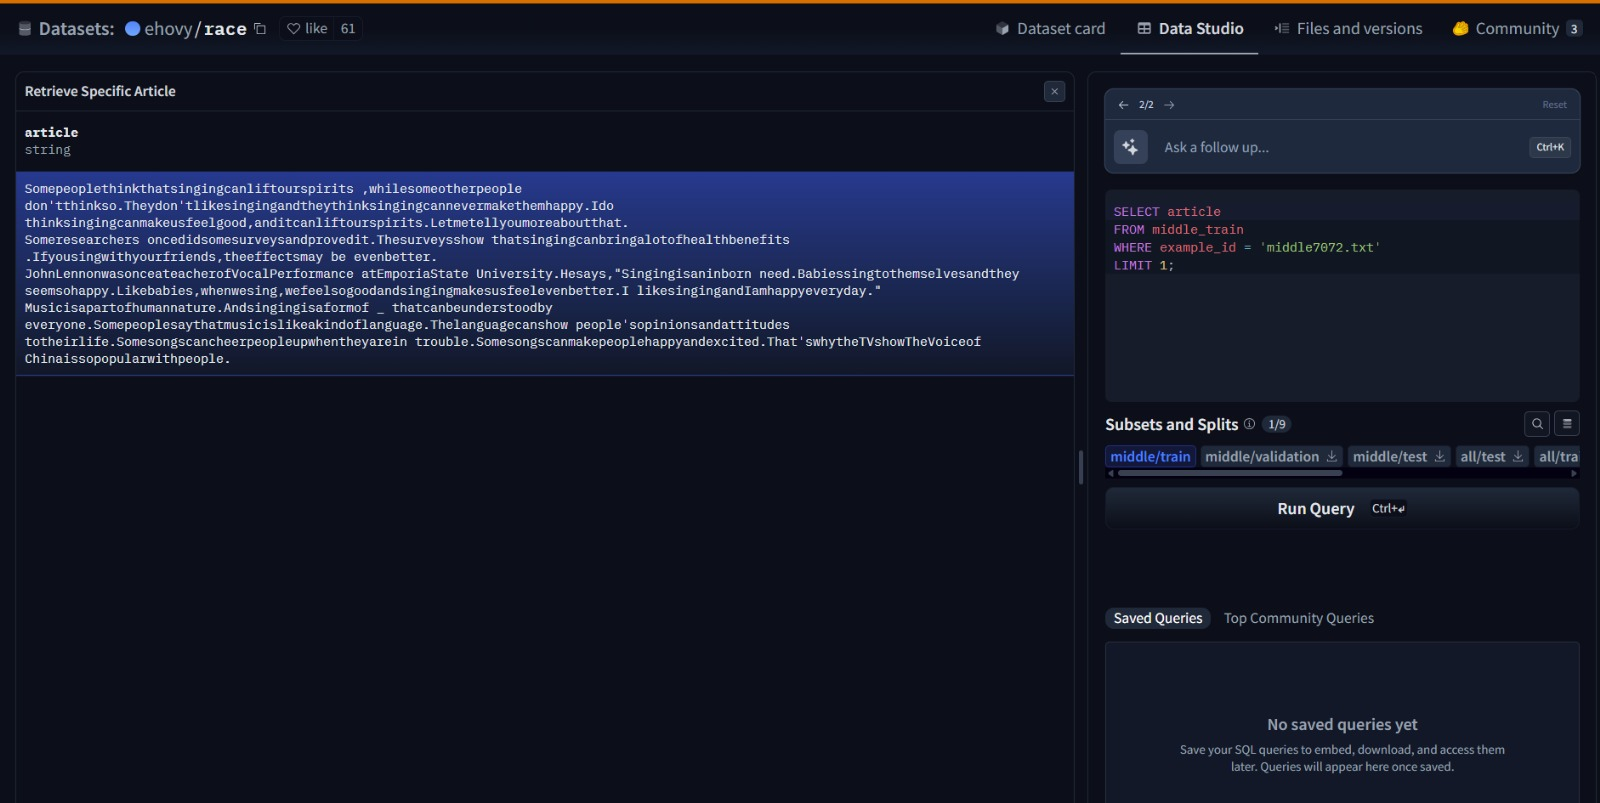

**Approach to Handling Merged Words**
To address this issue, we used the SplitNinja library, but only in cases where we detected unusually long words (those exceeding 15 characters). We avoided applying SplitNinja to the entire dataset for two key reasons:



1.   **Computational Efficiency:** Processing every document would have been unnecessarily resource-intensive.
2.   **Risk of Over-Splitting:** Since most articles were already correctly split, running SplitNinja universally could have introduced errors. The library works by first merging all words and then re-splitting them statistically, which might disrupt properly formatted text.


**Conclusion**
We opted for a conservative approach, applying SplitNinja only when we had strong evidence of merged words (e.g., extreme word length). While this strategy may have missed some edge cases or left minor errors uncorrected, it prioritized precision over coverage—a tradeoff we deemed necessary to maintain data integrity.



There is one last problem we had to face. Splitninja removed punctuation so we need a wrapper function to keep it:

In [ ]:
def smart_split(text, min_word_length=15):
    # 1) Normalize line breaks
    text = text.replace('.\n', ' . ')
    text = text.replace('\n', ' . ')

    # 2) Ensure long words ending with punctuation get separated from the next capitalized word
    #    (using only . ? ! for example; extend the class as you like)
    text = re.sub(r'(\b\w{3,})([.!?])\s*(\b[A-Z]\w{2,})',
                  r'\1 \2 \3',
                  text)

    # 3) Tokenize into “words” vs everything else
    tokens = re.findall(r'([A-Za-z]+|[^A-Za-z])', text)

    # 4) Rebuild with spaces after every token
    processed = []
    for token in tokens:
        if token.isalpha():
            # split long “words” into subwords
            processed.extend(wordninja.split(token))
        else:
            if(token!= ' '):
              processed.append(token)

    text = " ".join(processed)

    # 5) Clean up spaces before punctuation (e.g. remove the space before . ? ! , etc.)
    text = re.sub(r'(\w)\s+([.?!,;:—…])', r'\1\2', text)

    return text

Test to see if the word tokenizer works as expected:

In [ ]:
# Test
text = "Hello.World\nThisIsATest. Hello"
processed = smart_split(text)
processed

'Hello. World. This Is A Test. Hello'

unfortunately it has some problem when it comes to apostrophes but covering all case would cost me too much time.

In [ ]:
# Test
text = "I'm the best programmer cause I'\m the best"
processed = smart_split(text)
processed

"I ' m the best programmer cause I ' \\ m the best"

In [ ]:
def apply_wordninja_splitting(restructured_data, char_threshold=20):
    """
    Applies wordninja splitting ONLY to documents containing at least one
    word with more than `char_threshold` characters.
    """
    subsets = ['high', 'middle', 'all']
    splits = ['train', 'validation', 'test']

    for subset in subsets:
        for split in splits:
            data_for_subset = restructured_data[subset][split]
            for article_id in data_for_subset:
                original_text = data_for_subset[article_id]['article_text']

                # Check if document contains any long words
                has_long_word = any(
                    len(word) > char_threshold
                    for word in original_text.split()  # Simple space-based tokenization
                )

                # Apply wordninja only if long words detected
                if has_long_word:
                    print(subset + ' ' + split + ' ' + str(article_id))
                    processed_text = smart_split(original_text)
                    data_for_subset[article_id]['article_text'] = processed_text

    return restructured_data

dataset_dict=apply_wordninja_splitting(dataset_dict)

high train 25
high train 41
high train 123
high train 131
high train 145
high train 148
high train 155
high train 161
high train 162
high train 169
high train 171
high train 179
high train 187
high train 203
high train 217
high train 273
high train 309
high train 310
high train 318
high train 321
high train 324
high train 333
high train 345
high train 365
high train 369
high train 397
high train 398
high train 406
high train 408
high train 410
high train 413
high train 417
high train 425
high train 429
high train 436
high train 446
high train 448
high train 452
high train 459
high train 462
high train 474
high train 475
high train 491
high train 493
high train 519
high train 529
high train 530
high train 537
high train 555
high train 564
high train 574
high train 592
high train 606
high train 637
high train 640
high train 656
high train 659
high train 661
high train 671
high train 672
high train 673
high train 679
high train 684
high train 721
high train 736
high train 753
high train 7

Now if we check though for the previously critical datasets that had a lot of words unified it seems that they are not unified anymore

In [ ]:
middle_train_dict[21118]

{'article_text': 'Some people think that singing can lift our spirits, while some other people don \' t think so. They don \' t like singing and they think singing can never make them happy. Ido think singing can make us feelgood, and it can lift our spirits. Let me tell you more about that. Some researchers once did some surveys and proved it. The surveys show that singing can bring a lot of health benefits. If you sing with your friends, the effects may be even better. John Lennon was once a teacher of Vocal Performance at Emporia State University. He says, " Singing is an in born need. Babies sing to themselves and they seem so happy. Like babies, when we sing, we feel so good and singing makes us feel even better. I like singing and Iam happy everyday. " . Music is apart of human nature. And singing is a form of _ that can be understood by everyone. Some people say that music is like a kind of language. The language can show people \' s opinions and attitudes to their life. Some so

In [ ]:
high_train_dict[11910]

{'article_text': 'The United States has around 4 7 5, 0 0 0 school buses. Each day they carry more than 2 5 million children, half of all the schoolchildren in the country. These buses, on average, use 4 liters of diesel fuel to travel less than 1 6 kilometers. When the school year began last fall, diesel averaged 5 5 cents a liter nationally. The price nearly doubled by the end of school in June. Bob Riley is the spokesman for the American School Bus Council. He says fuel prices negotiated for schools are not lower than others have to pay. As a result, schools are looking for ways to reduce transportation costs. Bus routes are being redrawn or, in some cases, canceled. Some areas are buying buses that use natural gas or other alternative fuels. Other steps include fewer field trips and less travel by sports teams. Some school districts may end any bus service not required by law. Studies show that school buses are the safest form of transportation to and from school. The American Scho

This has a price though: normally long words like websites were divided. Moreover word Ninja computes decently fast but sometimes makes some small error so this is something to be noted.

## Analyzing difference of high school and middle school datasets

Pre built function to compute the number of syllable [source](https://stackoverflow.com/questions/46759492/syllable-count-in-python)

In [ ]:
def count_syllables(word):
    word = word.lower()

    # exception_add are words that need extra syllables
    # exception_del are words that need less syllables

    exception_add = ['serious','crucial']
    exception_del = ['fortunately','unfortunately']

    co_one = ['cool','coach','coat','coal','count','coin','coarse','coup','coif','cook','coign','coiffe','coof','court']
    co_two = ['coapt','coed','coinci']

    pre_one = ['preach']

    syls = 0 #added syllable number
    disc = 0 #discarded syllable number

    #1) if letters < 3 : return 1
    if len(word) <= 3 :
        syls = 1
        return syls

    #2) if doesn't end with "ted" or "tes" or "ses" or "ied" or "ies", discard "es" and "ed" at the end.
    # if it has only 1 vowel or 1 set of consecutive vowels, discard. (like "speed", "fled" etc.)

    if word[-2:] == "es" or word[-2:] == "ed" :
        doubleAndtripple_1 = len(re.findall(r'[eaoui][eaoui]',word))
        if doubleAndtripple_1 > 1 or len(re.findall(r'[eaoui][^eaoui]',word)) > 1 :
            if word[-3:] == "ted" or word[-3:] == "tes" or word[-3:] == "ses" or word[-3:] == "ied" or word[-3:] == "ies" :
                pass
            else :
                disc+=1

    #3) discard trailing "e", except where ending is "le"

    le_except = ['whole','mobile','pole','male','female','hale','pale','tale','sale','aisle','whale','while']

    if word[-1:] == "e" :
        if word[-2:] == "le" and word not in le_except :
            pass

        else :
            disc+=1

    #4) check if consecutive vowels exists, triplets or pairs, count them as one.

    doubleAndtripple = len(re.findall(r'[eaoui][eaoui]',word))
    tripple = len(re.findall(r'[eaoui][eaoui][eaoui]',word))
    disc+=doubleAndtripple + tripple

    #5) count remaining vowels in word.
    numVowels = len(re.findall(r'[eaoui]',word))

    #6) add one if starts with "mc"
    if word[:2] == "mc" :
        syls+=1

    #7) add one if ends with "y" but is not surrouned by vowel
    if word[-1:] == "y" and word[-2] not in "aeoui" :
        syls +=1

    #8) add one if "y" is surrounded by non-vowels and is not in the last word.

    for i,j in enumerate(word) :
        if j == "y" :
            if (i != 0) and (i != len(word)-1) :
                if word[i-1] not in "aeoui" and word[i+1] not in "aeoui" :
                    syls+=1

    #9) if starts with "tri-" or "bi-" and is followed by a vowel, add one.

    if word[:3] == "tri" and word[3] in "aeoui" :
        syls+=1

    if word[:2] == "bi" and word[2] in "aeoui" :
        syls+=1

    #10) if ends with "-ian", should be counted as two syllables, except for "-tian" and "-cian"

    if word[-3:] == "ian" :
    #and (word[-4:] != "cian" or word[-4:] != "tian") :
        if word[-4:] == "cian" or word[-4:] == "tian" :
            pass
        else :
            syls+=1

    #11) if starts with "co-" and is followed by a vowel, check if exists in the double syllable dictionary, if not, check if in single dictionary and act accordingly.

    if word[:2] == "co" and word[2] in 'eaoui' :

        if word[:4] in co_two or word[:5] in co_two or word[:6] in co_two :
            syls+=1
        elif word[:4] in co_one or word[:5] in co_one or word[:6] in co_one :
            pass
        else :
            syls+=1

    #12) if starts with "pre-" and is followed by a vowel, check if exists in the double syllable dictionary, if not, check if in single dictionary and act accordingly.

    if word[:3] == "pre" and word[3] in 'eaoui' :
        if word[:6] in pre_one :
            pass
        else :
            syls+=1

    #13) check for "-n't" and cross match with dictionary to add syllable.

    negative = ["doesn't", "isn't", "shouldn't", "couldn't","wouldn't"]

    if word[-3:] == "n't" :
        if word in negative :
            syls+=1
        else :
            pass

    #14) Handling the exceptional words.

    if word in exception_del :
        disc+=1

    if word in exception_add :
        syls+=1

    # calculate the output
    return numVowels - disc + syls

## Flesch Reading Ease Score

The Flesch Reading Ease score is calculated by considering sentence length and the number of syllables per word. Higher scores indicate easier reading. The Flesch Reading Ease formula calculates a score based on the average sentence length (words per sentence) and the average number of syllables per word.

| Score Range    | Reading Level               | School Level              |
|----------------|-----------------------------|---------------------------|
| 90-100         | Very Easy                   | 5th grade                 |
| 80-89          | Easy                        | 6th grade                 |
| 70-79          | Fairly Easy                 | 7th grade                 |
| 60-69          | Standard                    | 8th-9th grade             |
| 50-59          | Fairly Difficult            | 10th-12th grade           |
| 30-49          | Difficult                   | College                   |
| 0-29           | Very Difficult              | College Graduate          |

In [ ]:
def calculate_flesch_reading_ease(text):
    """
    Calculate the Flesch Reading Ease score for a text.
    Formula: 206.835 - 1.015 * (total_words / total_sentences) - 84.6 * (total_syllables / total_words)
    """
    sentences = loose_sentence_tokenize(text)
    total_sentences = len(sentences)

    if total_sentences == 0:
        return None

    words = [word.lower() for sentence in sentences for word in word_tokenize(sentence)
             if re.match(r'^[a-zA-Z]+$', word)]  # Only count alphabetic words
    total_words = len(words)

    if total_words == 0:
        return None

    total_syllables = sum(count_syllables(word) for word in words)

    asl = total_words / total_sentences  # Average Sentence Length
    asw = total_syllables / total_words  # Average Syllables per Word

    flesch_score = 206.835 - (1.015 * asl) - (84.6 * asw)

    return {
        'score': flesch_score,
        'avg_sentence_length': asl,
        'avg_syllables_per_word': asw,
        'total_sentences': total_sentences,
        'total_words': total_words,
        'total_syllables': total_syllables
    }


In [ ]:
text = "Hello.\nWorld\nHow are you? \n I'm fine."

text = text.replace('.\n', ' . ')
text = text.replace('\n', ' . ')

print(text)


Hello . World . How are you?  .  I'm fine.


### 🔧 Custom Loose Sentence Splitter


Most of the fixes we implemented involved correcting sentence formatting. Based on our experience, the NLTK word tokenizer assumes that a sentence ends after a period followed by a space ("."). However, many documents in the dataset did not follow this convention—some contained structures like "word.word" without a space, others started new lines with capital letters but no preceding period, and some used commas instead of periods.

To address this, we tried using a more flexible tokenizer with a heuristic that seemed reasonable. However, the numerous formatting inconsistencies in the dataset made the task much harder than expected—what should have been straightforward turned into an extremely challenging problem. We did our best with the data we had, but as the saying goes in NLP: **"Garbage in, garbage out."**

Article 12086 has \n but no full stop.

In [ ]:
high_train_dict[12086]

{'article_text': 'The reason for going to college has been accepted without question for more than a generation , All high school graduate ought to go , says conventional wisdom and statistical evidence, because college will help them earn more money, become "better" people , and learn to be more responsible citizens than those who don\'t go\nBut college has never been able to work its magic for everyone, And now that close to half our high school graduates are attending, those who don\'t fit the pattern are becoming more numerous, and more obvious, College graduates are selling shoes and driving taxis; college students interfere with each other\'s experiments and writhed false letters of recommendation in the intense competition for admission to graduate school, Others find no stimulation in their studies, and drop out-often encouraged by college  administrators\nSome observers say the fault is with the young people themselves-they are spoiled and they are expecting too much But that\

Article 6283 has not even a whitespace after using the dot.

In [ ]:
high_train_dict[6283]

{'article_text': 'Mass transportation revised the social and economic fabric  of the American city in three fundamental ways.It catalyzed  physical expansion, it sorted out people and land uses, and it accelerated the inherent instability of urban life.By opening vast areas of unoccupied land for residential expansion, the omnibuses, horse railways, commuter trains, and electric trolleys pulled settled regions outward two to four times more distant form city centers than they were in the premodern era.In 1850, for example, the borders of Boston lay scarcely two miles from the old business district; by the turn of the century the radius extended ten miles.Now those who could afford it could live far removed from the old city center and still commute there for work, shopping, and entertainment.The new accessibility of land around the periphery  of almost every major city sparked an explosion of real estate development and fueled what we now know as urban sprawl.Between 1890 and 1920, for

This is the reason why I used a looser regex sentence tokenizer in conjuction with the classic sent_tokenize(text) of NLTK.

Splits sentences only if a long word (≥4 chars) ends with punctuation and is followed by another long capitalized word — avoids splitting on abbreviations (e.g. Dr., 3.14) and handles messy text without spaces.

In [ ]:
def loose_sentence_tokenize(text):
    """
    NLTK-based sentence tokenizer with specific preprocessing for:
    1. Handling missing spaces after punctuation between long words (≥4 chars)
    2. Converting all newlines to period+space regardless of context

    Args:
        text (str): The input text to tokenize into sentences

    Returns:
        list: A list of sentence strings from NLTK's tokenizer
    """
    if not text:
        return []

    # Pre-processing step 1: Replace all newlines with period + space
    text = text.replace('.\n', '. ')
    text = text.replace('\n', '. ')

    # Pre-processing step 2: Add space after punctuation between long words
    # Pattern: word with 3+ chars ending with punctuation, followed by another word with 4+ chars starting with capital
    text = re.sub(r'(\b\w{3,}[.!?])(\b[A-Z]\w{2,})', r'\1 \2', text)

    # Use NLTK for the actual tokenization
    sentences = nltk.sent_tokenize(text)

    # Clean up results
    return [s.strip() for s in sentences if s.strip()]

In [ ]:
def analyze_article(article_text):
    """
    Compute all metrics for a single article
    """
    # Process sentences
    sentences = loose_sentence_tokenize(article_text)
    sentence_lengths = []
    for sentence in sentences:
        words = [word for word in word_tokenize(sentence) if re.match(r'^[a-zA-Z]+$', word)]
        if words:
            sentence_lengths.append(len(words))

    # Process words
    words = [word.lower() for word in word_tokenize(article_text) if re.match(r'^[a-zA-Z]+$', word)]
    text_length = len(words)

    # Process syllables
    syllables = [count_syllables(word) for word in words]

    # Process Flesch score
    flesch_result = calculate_flesch_reading_ease(article_text)
    flesch_score = flesch_result['score'] if flesch_result else None

    return {
        'sentence_lengths': sentence_lengths,
        'text_length': text_length,
        'words': words,
        'syllables': syllables,
        'flesch_score': flesch_score
    }

In [ ]:
def process_single_dataset(restructured_data, subset):
    """
    Process a single dataset and return its metrics
    """
    # Initialize metric aggregators
    sentence_lengths = []
    text_lengths = []
    all_words = []
    syllables_per_word = []
    flesch_scores = []

    data_for_subset = restructured_data[subset]['train']

    # Process each article
    for article_id in data_for_subset:
        article_metrics = analyze_article(data_for_subset[article_id]['article_text'])

        # Aggregate results
        sentence_lengths.extend(article_metrics['sentence_lengths'])
        text_lengths.append(article_metrics['text_length'])
        all_words.extend(article_metrics['words'])
        syllables_per_word.extend(article_metrics['syllables'])
        if article_metrics['flesch_score'] is not None:
            flesch_scores.append(article_metrics['flesch_score'])

    # Calculate metrics
    metrics = {
        'avg_sentence_length': np.mean(sentence_lengths) if sentence_lengths else 0,
        'avg_text_length': np.mean(text_lengths) if text_lengths else 0,
        'unique_words': len(set(all_words)),
        'total_words': len(all_words),
        'avg_syllables_per_word': np.mean(syllables_per_word) if syllables_per_word else 0,
        'flesch_reading_ease': np.mean(flesch_scores) if flesch_scores else 0
    }

    return {
        'metrics': metrics,
        'unique_words': set(all_words)  # Return the set for combined analysis
    }

In [ ]:
def analyze_datasets_difficulty(dataset):
    # Initialize combined metric aggregators
    all_unique_words = set()  # For tracking unique words across both datasets

    # Initialize results dictionary
    results = {}

    # Process first dataset
    subset1_metrics = process_single_dataset(dataset, 'high')
    results['high'] = subset1_metrics['metrics']
    all_unique_words.update(subset1_metrics['unique_words'])

    # Process second dataset
    subset2_metrics = process_single_dataset(dataset, 'middle')
    results['middle'] = subset2_metrics['metrics']
    all_unique_words.update(subset2_metrics['unique_words'])

    # Calculate shared words and remove them from all_unique_words
    shared_words = subset1_metrics['unique_words'] & subset2_metrics['unique_words']
    all_unique_words = all_unique_words - shared_words

    # Add unified vocabulary statistics
    results['combined_vocabulary'] = {
        'unique_words_count': len(all_unique_words),
        'unique_words_subset1_only': len(subset1_metrics['unique_words'] - subset2_metrics['unique_words']),
        'unique_words_subset2_only': len(subset2_metrics['unique_words'] - subset1_metrics['unique_words']),
        'shared_unique_words': len(shared_words),
    }

    return results, all_unique_words


===== HIGH SCHOOL VS MIDDLE SCHOOL DIFFICULTY ANALYSIS =====



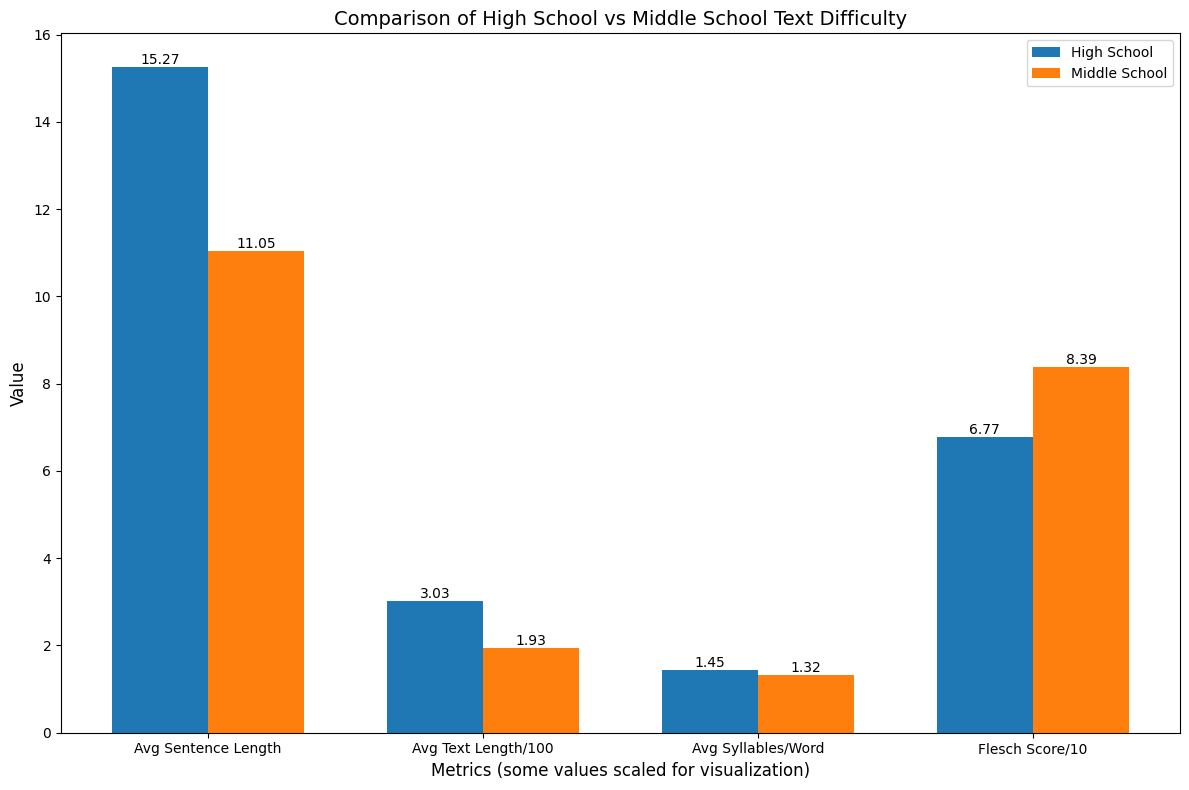


Detailed Comparison Table:
                         Metric High School Middle School Difference (High - Middle)
Average Sentence Length (words)       15.27         11.05                       4.22
    Average Text Length (words)      303.03        193.48                     109.55
             Unique Words Count       58804         17875                      40929
              Total Words Count     5674503       1240029                    4434474
     Average Syllables per Word       1.449         1.324                      0.125
      Flesch Reading Ease Score       67.71         83.92                     -16.21


In [ ]:
# Analyze both datasets
results, all_unique_words = analyze_datasets_difficulty(dataset_dict)
high_school_results = results['high']
middle_school_results = results['middle']

# Display results
print("\n===== HIGH SCHOOL VS MIDDLE SCHOOL DIFFICULTY ANALYSIS =====\n")

# Create visualization for the comparison
# **CHANGE 1**: Removed 'Vocabulary Richness*100' from metrics since no corresponding value is calculated
metrics = ['Avg Sentence Length', 'Avg Text Length/100',
           'Avg Syllables/Word', 'Flesch Score/10']

high_values = [
    high_school_results['avg_sentence_length'],
    high_school_results['avg_text_length']/100,  # Scale down for visualization
    high_school_results['avg_syllables_per_word'],  # Scale up for visualization
    high_school_results['flesch_reading_ease']/10  # Scale down for visualization
]

middle_values = [
    middle_school_results['avg_sentence_length'],
    middle_school_results['avg_text_length']/100,
    middle_school_results['avg_syllables_per_word'],
    middle_school_results['flesch_reading_ease']/10
]

# Set up plot
plt.figure(figsize=(12, 8))
x = np.arange(len(metrics))  # Now, x will have the correct shape based on the updated metrics list
width = 0.35

bars1 = plt.bar(x - width/2, high_values, width, label='High School')
bars2 = plt.bar(x + width/2, middle_values, width, label='Middle School')

plt.xlabel('Metrics (some values scaled for visualization)', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Comparison of High School vs Middle School Text Difficulty', fontsize=14)
plt.xticks(x, metrics) # **CHANGE 2**: Updated xticks with the correct metrics
plt.legend()

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.2f}', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()


# Create a detailed comparison table
comparison_df = pd.DataFrame({
    'Metric': [
        'Average Sentence Length (words)',
        'Average Text Length (words)',
        'Unique Words Count',
        'Total Words Count',
        'Average Syllables per Word',
        'Flesch Reading Ease Score'
    ],
    'High School': [
        f"{high_school_results['avg_sentence_length']:.2f}",
        f"{high_school_results['avg_text_length']:.2f}",
        f"{high_school_results['unique_words']}",
        f"{high_school_results['total_words']}",
        f"{high_school_results['avg_syllables_per_word']:.3f}",
        f"{high_school_results['flesch_reading_ease']:.2f}"
    ],
    'Middle School': [
        f"{middle_school_results['avg_sentence_length']:.2f}",
        f"{middle_school_results['avg_text_length']:.2f}",
        f"{middle_school_results['unique_words']}",
        f"{middle_school_results['total_words']}",
        f"{middle_school_results['avg_syllables_per_word']:.3f}",
        f"{middle_school_results['flesch_reading_ease']:.2f}"
    ],
    'Difference (High - Middle)': [
        f"{high_school_results['avg_sentence_length'] - middle_school_results['avg_sentence_length']:.2f}",
        f"{high_school_results['avg_text_length'] - middle_school_results['avg_text_length']:.2f}",
        f"{high_school_results['unique_words'] - middle_school_results['unique_words']}",
        f"{high_school_results['total_words'] - middle_school_results['total_words']}",
        f"{high_school_results['avg_syllables_per_word'] - middle_school_results['avg_syllables_per_word']:.3f}",
        f"{high_school_results['flesch_reading_ease'] - middle_school_results['flesch_reading_ease']:.2f}"
    ]
})

print("\nDetailed Comparison Table:")
print(comparison_df.to_string(index=False))

In [ ]:
# Using results['combined_vocabulary'] directly
vocab_data = results['combined_vocabulary']

# Prepare the data for the pie chart
labels = ['High school Only', 'Middle school Only', 'Shared unique Words']
sizes = [vocab_data['unique_words_high_only'],
         vocab_data['unique_words_middle_only'],
         vocab_data['shared_unique_words']]
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0.05, 0.05)  # slight separation between slices

# Create the pie chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct='%1.1f%%', shadow=True, startangle=140,
    textprops={'fontsize': 12}
)

# Make the percentages and labels more visible
plt.setp(autotexts, size=12, weight="bold")
plt.setp(texts, size=12)

plt.title(
    f'Vocabulary Distribution\n(Total Unique Words: {vocab_data["unique_words_count"]:,})',
    pad=20,
    fontsize=14,
    fontweight='bold'
)
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Add a legend with more details
legend_labels = [
    f'high school Only: {vocab_data["unique_words_high_only"]:,}',
    f'Middle school Only: {vocab_data["unique_words_middle_only"]:,}',
    f'Shared Words: {vocab_data["shared_unique_words"]:,}'
]
plt.legend(
    wedges,
    legend_labels,
    title="Word Counts",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

KeyError: 'unique_words_high_only'

Since there are a lot of shared words in the code above i prefereed to consider "unique" just the words not present in BOTH dataset.

In [ ]:
len(all_unique_words)

## POS tagging

We can count the number of adjectives and adverb to see if there is a particular difference between the middle and the high school dataset but there seems to not be any evident difference. NLTK's POS tagging is highly accurate (~95-100%) for simple, unambiguous text so probably the reason is that we do not have a particularly difficult text in both cases (or a text that makes frequet use of adverbs/adjectives).

In [ ]:
def analyze_pos_distribution(data, subset):
    """
    Analyze adjective and adverb usage in texts.
    Returns a list of dictionaries with POS statistics for each article.
    """
    # POS tags for adjectives and adverbs
    adjective_tags = ['JJ', 'JJR', 'JJS']  # Adjective, comparative, superlative
    adverb_tags = ['RB', 'RBR', 'RBS']  # Adverb, comparative, superlative

    results = []

    data_for_subset = data[subset]['train']
    # Process each article
    for article_id in data_for_subset:
        text = data_for_subset[article_id]['article_text']

        words = word_tokenize(text)
        pos_tags = pos_tag(words)

        # Count words (excluding punctuation)
        total_words = sum(1 for _, tag in pos_tags if tag[0] in 'NVRJACDPT')

        if total_words == 0:
            continue

        # Count adjectives and adverbs
        adjectives = sum(1 for _, tag in pos_tags if tag in adjective_tags)
        adverbs = sum(1 for _, tag in pos_tags if tag in adverb_tags)

        # Calculate percentages
        adj_percentage = (adjectives / total_words) * 100
        adv_percentage = (adverbs / total_words) * 100

        # Add to results
        results.append({
            'total_words': total_words,
            'adjectives': adjectives,
            'adverbs': adverbs,
            'adj_percentage': adj_percentage,
            'adv_percentage': adv_percentage,
            'adj_adv_percentage': adj_percentage + adv_percentage
        })

    return results


high_school_pos = analyze_pos_distribution(dataset_dict, 'high')
middle_school_pos = analyze_pos_distribution(dataset_dict, 'middle')


Dataset      | Adjectives   | Adverbs     
----------------------------------------
High School  | 9.47%      | 5.91%     
Middle School | 8.59%      | 6.48%     


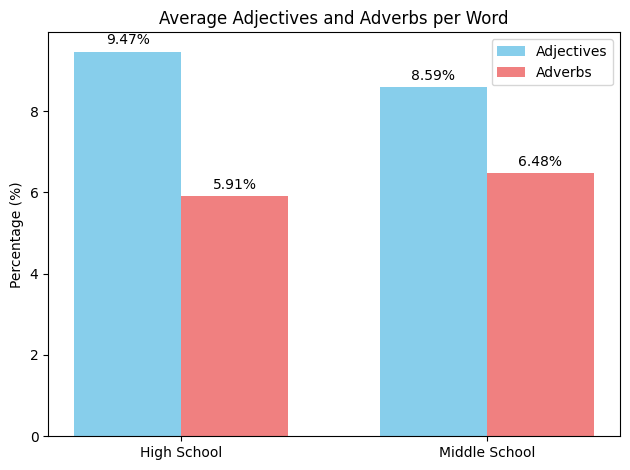

In [ ]:
def compute_averages(pos_data):
    """Compute average adjectives and adverbs per word across all articles."""
    total_adj = sum(article['adjectives'] for article in pos_data)
    total_adv = sum(article['adverbs'] for article in pos_data)
    total_words = sum(article['total_words'] for article in pos_data)
    avg_adj = total_adj / total_words if total_words != 0 else 0
    avg_adv = total_adv / total_words if total_words != 0 else 0
    return avg_adj, avg_adv

# Calculate averages for both subsets
high_adj_avg, high_adv_avg = compute_averages(high_school_pos)
middle_adj_avg, middle_adv_avg = compute_averages(middle_school_pos)

# Print results in a formatted table
print("\n{:<12} | {:<12} | {:<12}".format('Dataset', 'Adjectives', 'Adverbs'))
print("-" * 40)
print("{:<12} | {:<10.2%} | {:<10.2%}".format('High School', high_adj_avg, high_adv_avg))
print("{:<12} | {:<10.2%} | {:<10.2%}".format('Middle School', middle_adj_avg, middle_adv_avg))

# Create a grouped bar chart
labels = ['High School', 'Middle School']
adj_values = [high_adj_avg * 100, middle_adj_avg * 100]
adv_values = [high_adv_avg * 100, middle_adv_avg * 100]

x = range(len(labels))
width = 0.35  # Bar width

fig, ax = plt.subplots()
rects1 = ax.bar(x, adj_values, width, label='Adjectives', color='skyblue')
rects2 = ax.bar([p + width for p in x], adv_values, width, label='Adverbs', color='lightcoral')

ax.set_ylabel('Percentage (%)')
ax.set_title('Average Adjectives and Adverbs per Word')
ax.set_xticks([p + width/2 for p in x])
ax.set_xticklabels(labels)
ax.legend()

# Add percentage labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## Visualizing the results
We have gathered 4 distinctive features for the task of classification:


1.   Text length
2.   Word legth
3.   Sentence length
4.   Word rarity

The second and the third could be synthethized through the The Flesch Reading Ease score. So we can analyze each text and try to visualize it to see if we can



In [ ]:
def plot_readability_metrics_3d(restructured_data, all_unique_words):
    """
    Plot text length, Flesch reading score, and unique word count in an interactive 3D graph
    for articles from both 'high' and 'middle' subsets using Plotly.

    Parameters:
    - restructured_data: Dictionary containing the processed articles
    - all_unique_words: List of unique words to look for in the articles

    Returns:
    - Interactive plotly figure that can be rotated and explored
    """
    # Lists to store all the data points
    all_text_lengths = []
    all_flesch_scores = []
    all_unique_word_counts = []
    all_categories = []
    all_article_ids = []

    # Process each subset
    for subset in ['high', 'middle']:
        # Get data for this subset
        data_for_subset = restructured_data[subset]['train']

        # Process each article
        for article_id in data_for_subset:
            # Get metrics for this article
            article_metrics = analyze_article(data_for_subset[article_id]['article_text'])

            # Get text length
            text_length = article_metrics['text_length']

            # Get Flesch reading score
            flesch_score = article_metrics['flesch_score']
            if flesch_score is None:
                flesch_score = 0  # Default value if score is None

            # Count unique words from the given list that appear in the article
            article_words_set = set(article_metrics['words'])
            unique_word_count = sum(1 for word in all_unique_words if word.lower() in article_words_set)

            # Append metrics to respective lists
            all_text_lengths.append(text_length)
            all_flesch_scores.append(flesch_score)
            all_unique_word_counts.append(unique_word_count)
            all_categories.append('High School' if subset == 'high' else 'Middle School')
            all_article_ids.append(article_id)

    # Create a DataFrame for easier plotting with Plotly
    df = pd.DataFrame({
        'Text Length': all_text_lengths,
        'Flesch Score': all_flesch_scores,
        'Unique Word Count': all_unique_word_counts,
        'Category': all_categories,
        'Article ID': all_article_ids
    })

    # Create the 3D scatter plot using Plotly Express
    fig = px.scatter_3d(
        df,
        x='Text Length',
        y='Flesch Score',
        z='Unique Word Count',
        color='Category',
        color_discrete_map={'High School': 'red', 'Middle School': 'blue'},
        opacity=0.7,
        size_max=10,
        hover_data=['Article ID'],
        title='Interactive 3D Plot of Readability Metrics by School Level'
    )

    # Update layout for better appearance
    fig.update_layout(
        scene=dict(
            xaxis_title='Text Length (word count)',
            yaxis_title='Flesch Reading Score',
            zaxis_title='Unique Words Count',
            aspectmode='auto',
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="right",
            x=0.99
        )
    )

    # Add buttons for different preset views
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Reset View",
                        method="relayout",
                        args=[{"scene.camera.eye": dict(x=1.25, y=1.25, z=1.25),
                               "scene.camera.up": dict(x=0, y=0, z=1)}]
                    ),
                    dict(
                        label="Top View",
                        method="relayout",
                        args=[{"scene.camera.eye": dict(x=0, y=0, z=2.5),
                               "scene.camera.up": dict(x=0, y=1, z=0)}]
                    ),
                    dict(
                        label="Side View",
                        method="relayout",
                        args=[{"scene.camera.eye": dict(x=2.5, y=0, z=0),
                               "scene.camera.up": dict(x=0, y=0, z=1)}]
                    ),
                ],
                direction="down",
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.1,
                y=1.1,
                xanchor="left",
                yanchor="top",
            ),
        ]
    )

    # Show the figure
    fig.show()

    return fig

In [ ]:
fig = plot_readability_metrics_3d(dataset_dict, all_unique_words)
# To save the interactive plot to an HTML file that can be opened in any browser:
fig.write_html("readability_metrics_3d.html")

KeyboardInterrupt: 

There are some article which have insanely low Flesch reading score. The problem, upon further investigation, is the fact that, for some reason, they exchanged the dot with a comma. honestly I refuse to cover also this case. 😠

In [ ]:
high_train_dict[17572]

{'article_text': "The greatest recent changes have ,been in the lives of women ,During the twentieth century there was an unusual shortening of the time of a woman's life spent in caring for children. A woman marrying at the end of the 19th century would probably have been in her middle twenties ,and would be likely to have seven or eight children, of whom four or five lived till they were five years old ,By the time the youngest was fifteen ,the mother would have been id her early fifties and would expect to live a further twenty years ,during which custom ,chance and health made it unusual for her to get paid work, Today women marry younger and have fewer children Usually a woman 's youngest child will be fifteen when she is forty-five and is likely to take paid work until retirement at sixty Even while she has the care of children ,her work is lightened by household appliances  and convenience foods.\nThis important change in women's way of life has only recently begun to have its f

In [ ]:
analyze_article(high_train_dict[17572]['article_text'])

{'sentence_lengths': [32, 127, 154],
 'text_length': 313,
 'words': ['the',
  'greatest',
  'recent',
  'changes',
  'have',
  'been',
  'in',
  'the',
  'lives',
  'of',
  'women',
  'during',
  'the',
  'twentieth',
  'century',
  'there',
  'was',
  'an',
  'unusual',
  'shortening',
  'of',
  'the',
  'time',
  'of',
  'a',
  'woman',
  'life',
  'spent',
  'in',
  'caring',
  'for',
  'children',
  'a',
  'woman',
  'marrying',
  'at',
  'the',
  'end',
  'of',
  'the',
  'century',
  'would',
  'probably',
  'have',
  'been',
  'in',
  'her',
  'middle',
  'twenties',
  'and',
  'would',
  'be',
  'likely',
  'to',
  'have',
  'seven',
  'or',
  'eight',
  'children',
  'of',
  'whom',
  'four',
  'or',
  'five',
  'lived',
  'till',
  'they',
  'were',
  'five',
  'years',
  'old',
  'by',
  'the',
  'time',
  'the',
  'youngest',
  'was',
  'fifteen',
  'the',
  'mother',
  'would',
  'have',
  'been',
  'id',
  'her',
  'early',
  'fifties',
  'and',
  'would',
  'expect',
  '

In [ ]:
high_train_dict[12086]

{'article_text': 'The reason for going to college has been accepted without question for more than a generation , All high school graduate ought to go , says conventional wisdom and statistical evidence, because college will help them earn more money, become "better" people , and learn to be more responsible citizens than those who don\'t go\nBut college has never been able to work its magic for everyone, And now that close to half our high school graduates are attending, those who don\'t fit the pattern are becoming more numerous, and more obvious, College graduates are selling shoes and driving taxis; college students interfere with each other\'s experiments and writhed false letters of recommendation in the intense competition for admission to graduate school, Others find no stimulation in their studies, and drop out-often encouraged by college  administrators\nSome observers say the fault is with the young people themselves-they are spoiled and they are expecting too much But that\

There are also Article which scored more than 100 and the reason is because they are not even article to begin with. If we explore one of them, for example, we can see that it is just a list of thing with a price attached to them.

In [ ]:
middle_train_dict[23687]

{'article_text': 'Wen Feng Store Sale\nGoods     Colors     Price(each)\nSocks      Black, white, green $3\nSweater   Black      $15\nHat  Blue, white     $4\nT-shirt     Red, green      $14\nShoes      Black and white     $25\nBag  Blue $5\n,.',
 'questions': [{'example_id': 'middle1691.txt',
   'question': 'In all goods ,   _  is(are)cheap .',
   'options': ['Bag', 'Shoes', 'Hat', 'Socks'],
   'answer': 'D'},
  {'example_id': 'middle1691.txt',
   'question': 'Jack wants to buy two pairs of socks, one bag and two hats. How much are they?',
   'options': ['Twenty-one yuan.',
    'Nineteen yuan.',
    'Eighteen dollars.',
    'Nineteen dollars.'],
   'answer': 'D'},
  {'example_id': 'middle1691.txt',
   'question': 'Mary only likes blue, so she will buy  _  .',
   'options': ['socks and bag',
    'pants and sweater',
    'hat and bag',
    'shoes and hat'],
   'answer': 'C'},
  {'example_id': 'middle1691.txt',
   'question': 'The store has hats in  _  .',
   'options': ['all colors',
  

There are also high school articles with just 3 words... I guess someone has forgotten to paste the text article... ⚡

In [ ]:
high_train_dict[11334]

{'article_text': 'STUDY CENTER COURSES',
 'questions': [{'example_id': 'high16098.txt',
   'question': "If a student takes the course The Short Story, he can't take    _    .",
   'options': ['From Paragraph to Essay',
    'Tense about Tenses',
    'Source Material',
    'Media Use'],
   'answer': 'A'},
  {'example_id': 'high16098.txt',
   'question': "Which of the courses can develop the students' team work?",
   'options': ['From Paragraph to Essay',
    'The Short Story',
    'Caught for Speeding',
    'Express Yourself'],
   'answer': 'B'},
  {'example_id': 'high16098.txt',
   'question': 'From where can a student read this?',
   'options': ['On the radio.',
    'On television.',
    'In a local newspaper.',
    'On a school notice board.'],
   'answer': 'D'}]}

## RECAP OF THE DATA STRUCTURE WE EXTRACTED
**dataset_dict**

This dictionary contains educational questions divided into subsets based on school level:
- **middle**: Contains middle school level questions
- **high**: Contains high school level questions
- **complete**: Combined set of both high school and middle school questions

Each question is associated with an article that provides the context for the question. The `article_id` serves as the key to access its corresponding questions and the text of the article.

```
dataset_dict
├── 'all'/'high'/'middle' (subset)
│   ├── 'train'/'validation'/'test' (split)
│   │   ├── article_id: int (key)
│   │   │   ├── 'article_text': str
│   │   │   └── 'questions': list
│   │   │       ├── {'example_id': str, 'question': str, 'options': list, 'answer': str}
│   │   │       └── ...more questions
```

We also have the following dictionaries that refers to just a partition of the whole dataset_dict that can be used to access the articles by their id that are just inside that specific partition.
```
middle_train_dict
high_train_dict
complete_train_dic

middle_validation_dict
high_validation_dict
complete_validation_dict


middle_test_dict
high_test_dict
complete_test_dict
```

# **TEXT CLASSIFIER**

In this section we will try to build a classification model for our dataset. The classes we will build our model for are:
* article for high school
* article for middle school

In order to do so, we will use the following features:
* unique words count (how many words in the article appear only in that specific article)
* average sentence length
* text_lenght
* words (using the **Bag-Of-Words** representation)

We will obtain these metrics from the *analyze_article* method.

We will try different classifiers:
* Multinomial Naive Bayes Classifier
* Logistic Regression
* Support Vector Machine
* perceptron classifier

Since we happen to have many features, we will need strong regularization. We will use l-1 regularization, because we aim to some parameters to get to zero, it will mean that some words will not be relevant for the classification problem.

First we will also need to compute a BOW representation of documents, since it will be useful for using words as features.

## Extracting the features

Before building our classifiers, we need to extract our features. We will analyze our articles and build a BOW representation for them.

In [ ]:
import re
# we will use the complete dataset
articles_x = list(dataset_complete['train'])

# we need to delete duplicates in the article fields
seen_articles = set()
articles_x = [d for d in articles_x if d['article'] not in seen_articles and not seen_articles.add(d['article'])]

# for the labels, we will extract it from the example_id field of the sample
regex = '(.*?)\d+'

articles_y = []
for article in articles_x:
    label = article['example_id']
    label = re.match(regex, label).group(1)
    articles_y.append(label)

# print the first
print(articles_x[0])
print(articles_y[0])

{'example_id': 'high19088.txt', 'article': 'Last week I talked with some of my students about what they wanted to do after they graduated, and what kind of job prospects  they thought they had.\nGiven that I teach students who are training to be doctors, I was surprised do find that most thought that they would not be able to get the jobs they wanted without "outside help". "What kind of help is that?" I asked, expecting them to tell me that they would need a   or family friend to help them out.\n"Surgery ," one replied.\nI was pretty alarmed by that response. It seems that the graduates of today are increasingly willing to go under the knife to get ahead of others when it comes to getting a job .\nOne girl told me that she was considering surgery to increase her height. "They break your legs, put in special extending screws, and slowly expand the gap between the two ends of the bone as it re-grows, you can get at least 5 cm taller!"\nAt that point, I was shocked. I am short, I can\'t 

Great! Now we want to analyze every doc present in articles_x

In [ ]:
from tqdm.notebook import tqdm

analyzed_x_articles = []
for article in tqdm(articles_x):
    analyzed_x_articles.append(analyze_article(article['article']))

  0%|          | 0/25135 [00:00<?, ?it/s]

In [ ]:
articles_x = analyzed_x_articles

In [ ]:
print(articles_x[129])

{'sentence_lengths': [6, 19, 18, 20, 8, 15, 20, 12, 5, 8, 15, 14, 28, 12, 18, 30, 12, 4, 10, 12, 7, 23, 22, 7, 3, 22, 19, 28], 'text_length': 417, 'words': ['my', 'mother', 'was', 'a', 'household', 'servant', 'through', 'her', 'work', 'she', 'observed', 'that', 'successful', 'people', 'spent', 'a', 'lot', 'more', 'time', 'reading', 'than', 'they', 'did', 'watching', 'television', 'she', 'announced', 'that', 'my', 'brother', 'and', 'i', 'could', 'only', 'watch', 'two', 'to', 'three', 'tv', 'programs', 'during', 'the', 'week', 'with', 'our', 'free', 'time', 'we', 'had', 'to', 'read', 'two', 'books', 'each', 'from', 'the', 'detroit', 'public', 'library', 'and', 'write', 'book', 'reports', 'she', 'would', 'mark', 'them', 'up', 'with', 'check', 'marks', 'years', 'later', 'we', 'realized', 'her', 'marks', 'were', 'a', 'my', 'mother', 'had', 'only', 'received', 'a', 'education', 'although', 'we', 'had', 'no', 'money', 'between', 'the', 'covers', 'of', 'those', 'books', 'i', 'could', 'go', 'an

Now we can vectorize the words of the text using CountVectorizer from scikit-learn.

We will remove the stopwords, since they will not be useful for classification. We will also consider only those words that appear at least in 10 documents, since otherwise we will not have enough data for a correct classification.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(min_df=10, stop_words='english')
X = vectorizer.fit([word for article in articles_x for word in article['words']])
print(len(vectorizer.get_feature_names_out()))

15727


The size of the vocabulary obtained is: 15727 words.

Now we can work with an amount of words that appeared regularly throuhout the dataset. Let's print some of the selected words.

In [ ]:
print(vectorizer.get_feature_names_out()[:1000])

['aa' 'aaron' 'ab' 'abandon' 'abandoned' 'abandoning' 'abbey' 'abbott'
 'abbreviations' 'abc' 'abdomen' 'abdominal' 'abe' 'aberdeen' 'abilities'
 'ability' 'able' 'abnormal' 'aboard' 'aboriginal' 'abraham' 'abroad'
 'absence' 'absences' 'absent' 'absolute' 'absolutely' 'absorb' 'absorbed'
 'absorbing' 'absorption' 'abstract' 'absurd' 'abundance' 'abundant'
 'abuse' 'abused' 'abusive' 'ac' 'academia' 'academic' 'academically'
 'academics' 'academies' 'academy' 'acc' 'accelerate' 'accelerated'
 'accelerator' 'accent' 'accents' 'accept' 'acceptable' 'acceptance'
 'accepted' 'accepting' 'accepts' 'access' 'accessed' 'accessibility'
 'accessible' 'accessories' 'accident' 'accidental' 'accidentally'
 'accidents' 'accommodate' 'accommodation' 'accommodations' 'accompanied'
 'accompany' 'accompanying' 'accomplish' 'accomplished' 'accomplishing'
 'accomplishment' 'accomplishments' 'accordance' 'according' 'accordingly'
 'accordion' 'account' 'accountant' 'accountants' 'accounted' 'accounting'
 

Now we can generate the Bag-Of-Words representation of the train set

In [ ]:
# join the words in the 'words' field of an article for each articles_x
articles_x_words = [' '.join(article['words']) for article in articles_x]

train_x_vector = vectorizer.transform(articles_x_words)
train_x_vector

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2227183 stored elements and shape (25135, 15727)>

Now we can try to look at some articles, the length of the sparse vector representation and the number of unique words in the article.

Furthermore we will print the sparse vector and the intersection of the vocabulary and the article.

In [ ]:
import random
i = random.randrange(len(articles_x))

print('Random article:')
print(articles_x[i])

print('\nLen of sparse vector:')
print(len(train_x_vector[i].nonzero()[1]))

print('\nNumber of unique words in the article:')
print(len(set(articles_x[i]['words'])))

print('\nSparse vector:')
print(train_x_vector[i])

vocab = vectorizer.get_feature_names_out()
print('\nVocabulary of article:')
[(j,vocab[j]) for j in train_x_vector[i].nonzero()[1]]

Random article:
{'sentence_lengths': [15, 11, 10, 18, 18, 27, 24, 9, 22, 28, 8, 15, 11, 6, 13, 10, 2, 11, 10, 6, 11, 1, 8, 20, 31, 11, 9, 38], 'text_length': 403, 'words': ['my', 'grandfather', 'had', 'a', 'small', 'farm', 'where', 'he', 'raised', 'beef', 'and', 'some', 'grain', 'for', 'feed', 'he', 'also', 'worked', 'diligently', 'as', 'a', 'factory', 'laborer', 'and', 'country', 'pastor', 'he', 'was', 'a', 'good', 'neighbor', 'and', 'for', 'honoring', 'his', 'word', 'when', 'harvest', 'time', 'came', 'he', 'piece', 'together', 'his', 'old', 'corn', 'picker', 'and', 'oil', 'it', 'up', 'for', 'the', 'season', 'all', 'his', 'life', 'he', 'worked', 'hard', 'helped', 'others', 'and', 'you', 'could', 'count', 'on', 'him', 'to', 'keep', 'his', 'promises', 'he', 'had', 'promised', 'to', 'harvest', 'a', 'few', 'ribbons', 'of', 'corn', 'on', 'a', 'friend', 'farm', 'but', 'after', 'harvesting', 'his', 'own', 'corn', 'grandpa', 'little', 'corn', 'picker', 'coughed', 'and', 'quit', 'it', 'would',

[(np.int32(327), 'aha'),
 (np.int32(780), 'asked'),
 (np.int32(949), 'autumn'),
 (np.int32(1225), 'beef'),
 (np.int32(1236), 'began'),
 (np.int32(1551), 'bookshelf'),
 (np.int32(1713), 'brilliant'),
 (np.int32(1894), 'ca'),
 (np.int32(1939), 'called'),
 (np.int32(1960), 'came'),
 (np.int32(2546), 'clear'),
 (np.int32(2677), 'cold'),
 (np.int32(2694), 'collect'),
 (np.int32(2780), 'commission'),
 (np.int32(3149), 'corn'),
 (np.int32(3152), 'corners'),
 (np.int32(3193), 'coughed'),
 (np.int32(3200), 'count'),
 (np.int32(3211), 'country'),
 (np.int32(3327), 'crops'),
 (np.int32(3428), 'cut'),
 (np.int32(3432), 'cutting'),
 (np.int32(3523), 'dawn'),
 (np.int32(3532), 'days'),
 (np.int32(3716), 'depending'),
 (np.int32(3894), 'dilemma'),
 (np.int32(3909), 'dinner'),
 (np.int32(4113), 'does'),
 (np.int32(4839), 'exactly'),
 (np.int32(5032), 'factory'),
 (np.int32(5090), 'far'),
 (np.int32(5097), 'farm'),
 (np.int32(5099), 'farmer'),
 (np.int32(5100), 'farmers'),
 (np.int32(5172), 'feed'),
 (

Now we want to create the sample to give to our learners. They will have the following features:
* average sentence lenght
* text lenght
* flesh score
* BOW representation of the article

In [ ]:
def transform_sample(sample, bow, all_unique_words):
    # get the average sentence lenght
    avg_sentence_length = np.mean(sample['sentence_lengths'])
    avg_sentence_length = float(avg_sentence_length)

    # get the unique word count
    article_words_set = set(sample['words'])
    unique_word_count = sum(1 for word in all_unique_words if word.lower() in article_words_set)

    # get the text lenght
    text_lenght = sample['text_length']

    # combine the features
    features = [unique_word_count, avg_sentence_length, text_lenght] + bow.toarray().tolist()[0]
    return features

train_x = np.zeros((len(articles_x), train_x_vector.shape[1] + 3), dtype=np.float64)
for idx in tqdm(range(len(articles_x))):
    bow = train_x_vector[idx]
    train_x[idx] = transform_sample(articles_x[idx], bow, all_unique_words)


  0%|          | 0/25135 [00:00<?, ?it/s]

In [ ]:
print(train_x[129])

[  6.          14.89285714 417.         ...   0.           0.
   0.        ]


Now that we have our data ready, we can start building our classifiers.

## Transform also validation and test

Now we need to transform the validation and test set in the same way, so that we can work with them

In [ ]:
regex = '(.*?)\d+'

# define the samples and labels
validation_x = list(dataset_complete['validation'])
validation_y = []
for article in validation_x:
    label = article['example_id']
    label = re.match(regex, label).group(1)
    validation_y.append(label)

# analyze each article
analyze_article_validation = []
for article in tqdm(validation_x):
    analyze_article_validation.append(analyze_article(article['article']))

validation_x = analyze_article_validation

# compute the BOW representation
articles_x_validation_words = [' '.join(article['words']) for article in validation_x]
validation_x_vector = vectorizer.transform(articles_x_validation_words)

# tranform the samples
val_x = np.zeros((len(validation_x), train_x_vector.shape[1] + 3), dtype=np.float64)
for idx in tqdm(range(len(validation_x))):
    bow = validation_x_vector[idx]
    val_x[idx] = transform_sample(validation_x[idx], bow, all_unique_words)


  0%|          | 0/4887 [00:00<?, ?it/s]

  0%|          | 0/4887 [00:00<?, ?it/s]

Now we do the same with the test set

In [ ]:
regex = '(.*?)\d+'

# define the samples and labels
testing_x = list(dataset_complete['test'])
testing_y = []
for article in testing_x:
    label = article['example_id']
    label = re.match(regex, label).group(1)
    testing_y.append(label)

# analyze each article
analyze_article_test = []
for article in tqdm(testing_x):
    analyze_article_test.append(analyze_article(article['article']))

testing_x = analyze_article_test

# compute the BOW representation
articles_x_test_words = [' '.join(article['words']) for article in testing_x]
test_x_vector = vectorizer.transform(articles_x_test_words)

# tranform the samples
test_x = np.zeros((len(testing_x), train_x_vector.shape[1] + 3), dtype=np.float64)

for idx in tqdm(range(len(testing_x))):
    bow = test_x_vector[idx]
    test_x[idx] = transform_sample(testing_x[idx], bow, all_unique_words)


  0%|          | 0/4934 [00:00<?, ?it/s]

  0%|          | 0/4934 [00:00<?, ?it/s]

## Naive Bayes Estimator

The Naive Bayes estimator is a probabilistic classifier based on applying Bayes' theorem with strong (naive) independence assumptions between the features.

For the project's purpose we will use two different implementations from scikit-learn:
* MultinomialNB: suitable for discrete features, used in text classification
* ComplementNB: variant of MultinomialNB suited for imbalanced datasets. This one might be our case since the number of *high school* articles is three times the one of *middle school* ones

We will use our validation set to find the best value for $\alpha$, which is a smoothing parameter used to address the issue of zero probability in feature counts.

In [ ]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_model_NB = None
best_accuracy_NB = 0
best_alpha_NB = None
best_confusion_NB = None
best_report_NB = None
best_model_CB = None
best_accuracy_CB = 0
best_alpha_CB = None
best_confusion_CB = None
best_report_CB = None

for alpha in tqdm(alpha_values):
    model_NB = MultinomialNB(alpha=alpha).fit(train_x, articles_y)
    model_CB = ComplementNB(alpha=alpha).fit(train_x, articles_y)
    y_pred_NB = model_NB.predict(val_x)
    y_pred_CB = model_CB.predict(val_x)
    accuracy_NB = accuracy_score(validation_y, y_pred_NB)
    accuracy_CB = accuracy_score(validation_y, y_pred_CB)
    print(f'=================================== alpha={alpha}: \nAccuracy NB: {accuracy_NB}\nAccuracy CB: {accuracy_CB}\n')
    # print the reports
    print(f'Classification report for NB with alpha={alpha}:')
    print(classification_report(validation_y, y_pred_NB, zero_division=1))
    print('\n')
    print(f'Classification report for CB with alpha={alpha}:')
    print(classification_report(validation_y, y_pred_CB, zero_division=1))
    print('\n\n')
    if accuracy_NB > best_accuracy_NB:
        best_accuracy_NB = accuracy_NB
        best_model_NB = model_NB
        best_alpha_NB = alpha
        best_confusion_NB = confusion_matrix(validation_y, y_pred_NB, labels=['high', 'middle'])
        best_report_NB = classification_report(validation_y, y_pred_NB, zero_division=1)

    if accuracy_CB > best_accuracy_CB:
        best_accuracy_CB = accuracy_CB
        best_model_CB = model_CB
        best_alpha_CB = alpha
        best_confusion_CB = confusion_matrix(validation_y, y_pred_CB, labels=['high', 'middle'])
        best_report_CB = classification_report(validation_y, y_pred_CB, zero_division=1)

print(f'Best alpha for NB: {best_alpha_NB}')
print(f'Best accuracy for NB: {best_accuracy_NB}\n')
print(f'Best alpha for CB: {best_alpha_CB}')
print(f'Best accuracy for CB: {best_accuracy_CB}')

  0%|          | 0/7 [00:00<?, ?it/s]

=================================== alpha=0.001: 
Accuracy NB: 0.8381420094127277
Accuracy CB: 0.833231021076325

Classification report for NB with alpha=0.001:
              precision    recall  f1-score   support

        high       0.92      0.85      0.88      3451
      middle       0.69      0.82      0.75      1436

    accuracy                           0.84      4887
   macro avg       0.80      0.83      0.81      4887
weighted avg       0.85      0.84      0.84      4887



Classification report for CB with alpha=0.001:
              precision    recall  f1-score   support

        high       0.92      0.84      0.88      3451
      middle       0.68      0.82      0.74      1436

    accuracy                           0.83      4887
   macro avg       0.80      0.83      0.81      4887
weighted avg       0.85      0.83      0.84      4887




=================================== alpha=0.01: 
Accuracy NB: 0.8340495191323921
Accuracy CB: 0.832207898506241

Classification repor

Let's take a look at the information our best models gave us:

================================== Multinomial Naive Bayes ==================================
Best accuracy: 0.8414160016369961



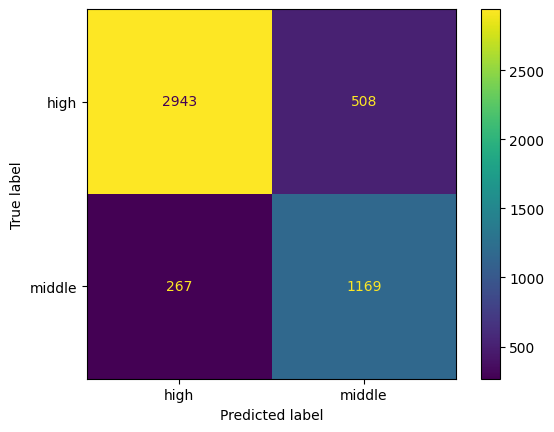

              precision    recall  f1-score   support

        high       0.92      0.85      0.88      3451
      middle       0.70      0.81      0.75      1436

    accuracy                           0.84      4887
   macro avg       0.81      0.83      0.82      4887
weighted avg       0.85      0.84      0.84      4887




================================== Complement Naive Bayes ==================================
Best accuracy: 0.8334356455903418



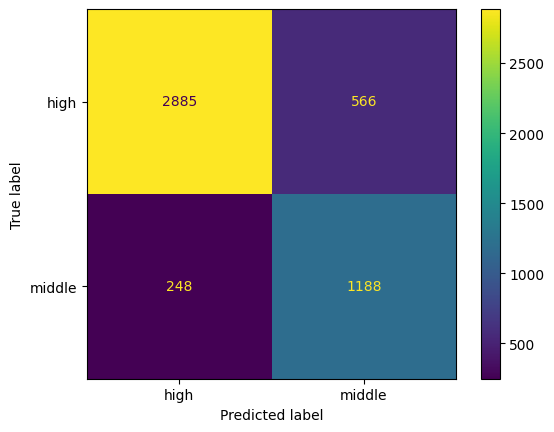

              precision    recall  f1-score   support

        high       0.92      0.84      0.88      3451
      middle       0.68      0.83      0.74      1436

    accuracy                           0.83      4887
   macro avg       0.80      0.83      0.81      4887
weighted avg       0.85      0.83      0.84      4887






In [ ]:
print('================================== Multinomial Naive Bayes ==================================')
print(f'Best accuracy: {best_accuracy_NB}\n')
disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_NB, display_labels=['high', 'middle'])
disp.plot()
plt.show()
print(best_report_NB)
print('\n\n')

print('================================== Complement Naive Bayes ==================================')
print(f'Best accuracy: {best_accuracy_CB}\n')
disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_CB, display_labels=['high', 'middle'])
disp.plot()
plt.show()
print(best_report_CB)
print('\n\n')

Let's test our model on the test-set:

================================== Multinomial Naive Bayes ==================================
Accuracy: 0.8323875152006486


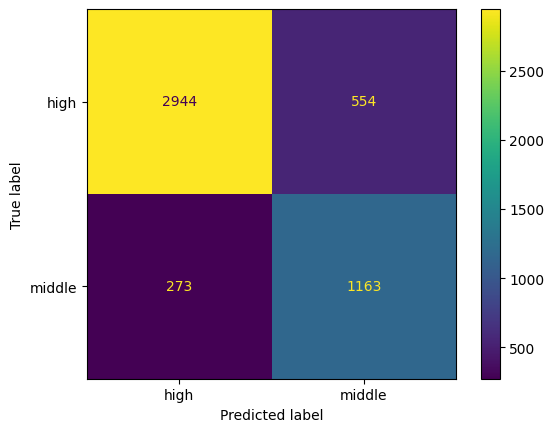

              precision    recall  f1-score   support

        high       0.92      0.84      0.88      3498
      middle       0.68      0.81      0.74      1436

    accuracy                           0.83      4934
   macro avg       0.80      0.83      0.81      4934
weighted avg       0.85      0.83      0.84      4934



================================== Complement Naive Bayes ==================================
Accuracy: 0.8293473854884476


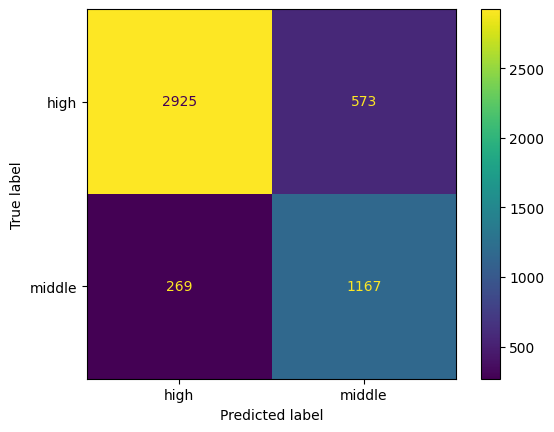

              precision    recall  f1-score   support

        high       0.92      0.84      0.87      3498
      middle       0.67      0.81      0.73      1436

    accuracy                           0.83      4934
   macro avg       0.79      0.82      0.80      4934
weighted avg       0.84      0.83      0.83      4934



In [ ]:
print('================================== Multinomial Naive Bayes ==================================')
predictions = best_model_NB.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))

print('\n\n================================== Complement Naive Bayes ==================================')
predictions = best_model_CB.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))

We obtained similar results with the two models:

**Multinomial Naive Bayes Classifier**
* overall accuracy: $83,2\%$
* *high* class f1-score: $88\%$
* *middle* class f1-score: $74\%$

**Complement Naive Bayes Classifier**
* overall accuracy: $83\%$
* *high* class f1-score: $87\%$
* *middle* class f1-score: $73\%$

These are good results, unfortunately the model mispredicts a lot of middle school articles. This is probably happening because of the unbalanced dataset, since the number of high school articles is roughly three times the one of middle school articles.

Furthermore, since the *Complement Naive Bayes Classfier* is optimized for unbalanced datasets, and we did not observe a substancial improvement, this means that we cannot do much about this problem.

## Logistic regression model

Logistic Regression is a widely used statistical method for predicting the probability of a binary outcome. Unlike linear regression, which predicts continuous values, logistic regression models the relationship between predictor variables and a categorical dependent variable. It employs a sigmoid function to transform a linear combination of features into a probability score between 0 and 1, representing the likelihood of the event occurring.

We will use the scikit-learn implementation of the method.

Using our validation set, we will address the problem of finding the best value for **C**, our regularization parameter.

For the regularization penalty, we will use the $l-1$ regularization, since it is very useful when dealing with text and ***Bag-Of-words*** representations, since it can set to zero those parameters that are not useful for the classification problem.

  0%|          | 0/7 [00:00<?, ?it/s]

=================================== C=0.001: 
Accuracy: 0.8086760793943114



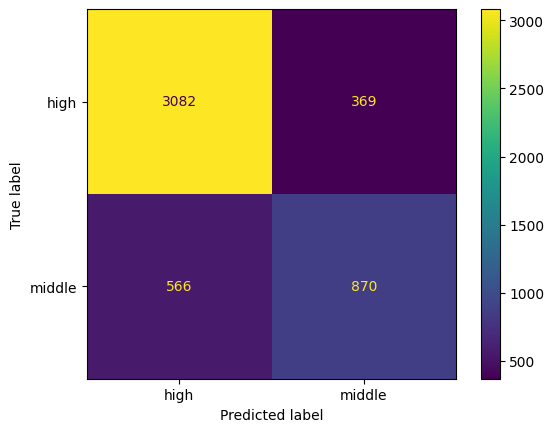

              precision    recall  f1-score   support

        high       0.84      0.89      0.87      3451
      middle       0.70      0.61      0.65      1436

    accuracy                           0.81      4887
   macro avg       0.77      0.75      0.76      4887
weighted avg       0.80      0.81      0.80      4887




=================================== C=0.01: 
Accuracy: 0.8493963576836505



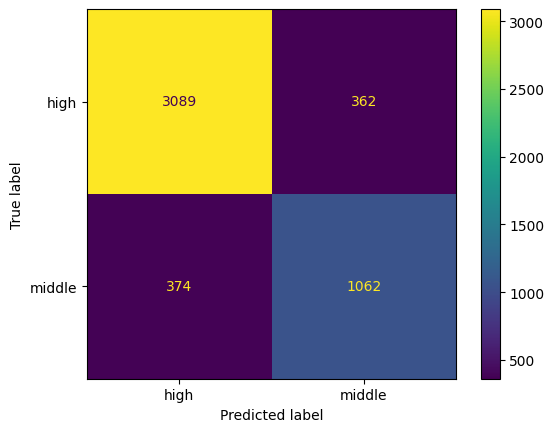

              precision    recall  f1-score   support

        high       0.89      0.90      0.89      3451
      middle       0.75      0.74      0.74      1436

    accuracy                           0.85      4887
   macro avg       0.82      0.82      0.82      4887
weighted avg       0.85      0.85      0.85      4887




=================================== C=0.1: 
Accuracy: 0.8729281767955801



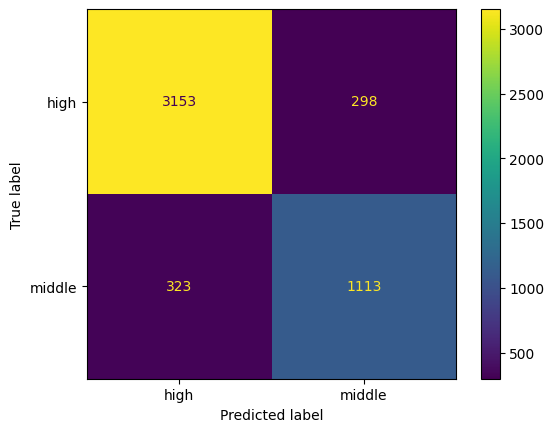

              precision    recall  f1-score   support

        high       0.91      0.91      0.91      3451
      middle       0.79      0.78      0.78      1436

    accuracy                           0.87      4887
   macro avg       0.85      0.84      0.85      4887
weighted avg       0.87      0.87      0.87      4887




=================================== C=1: 
Accuracy: 0.8680171884591774



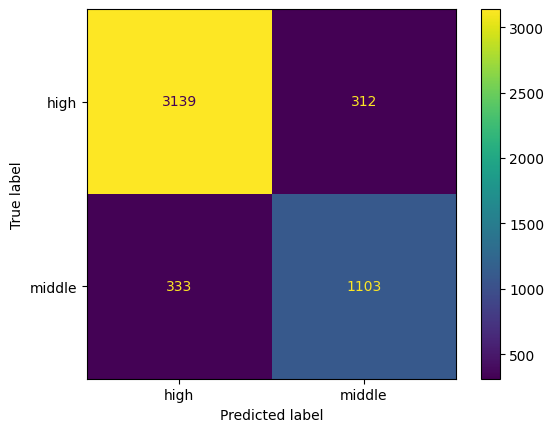

              precision    recall  f1-score   support

        high       0.90      0.91      0.91      3451
      middle       0.78      0.77      0.77      1436

    accuracy                           0.87      4887
   macro avg       0.84      0.84      0.84      4887
weighted avg       0.87      0.87      0.87      4887




=================================== C=10: 
Accuracy: 0.8514426028238183



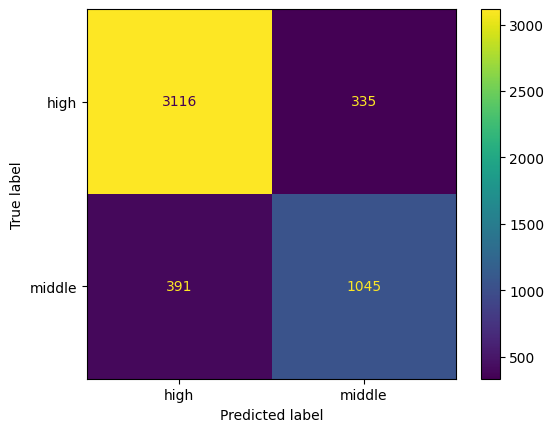

              precision    recall  f1-score   support

        high       0.89      0.90      0.90      3451
      middle       0.76      0.73      0.74      1436

    accuracy                           0.85      4887
   macro avg       0.82      0.82      0.82      4887
weighted avg       0.85      0.85      0.85      4887




=================================== C=100: 
Accuracy: 0.8344587681604256



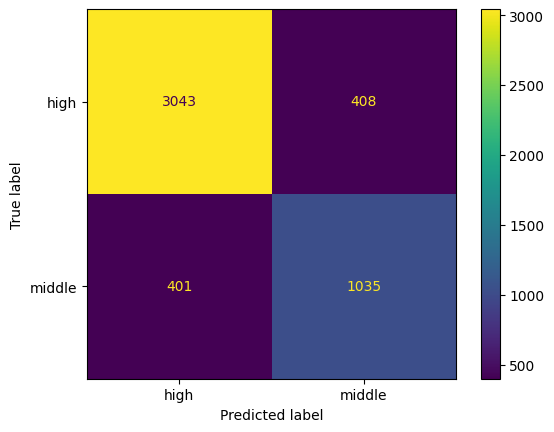

              precision    recall  f1-score   support

        high       0.88      0.88      0.88      3451
      middle       0.72      0.72      0.72      1436

    accuracy                           0.83      4887
   macro avg       0.80      0.80      0.80      4887
weighted avg       0.83      0.83      0.83      4887




=================================== C=1000: 
Accuracy: 0.8340495191323921



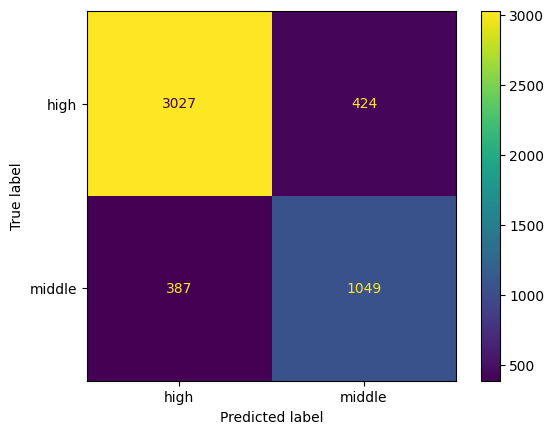

              precision    recall  f1-score   support

        high       0.89      0.88      0.88      3451
      middle       0.71      0.73      0.72      1436

    accuracy                           0.83      4887
   macro avg       0.80      0.80      0.80      4887
weighted avg       0.84      0.83      0.83      4887




Best C: 0.1
Best accuracy: 0.8729281767955801


In [ ]:
from sklearn.linear_model import LogisticRegression


C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_model = None
best_accuracy = 0
best_C = None
best_confusion = None
best_report = None

for C in tqdm(C_values):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C).fit(train_x, articles_y)
    transformed_validation = model.predict(val_x)
    accuracy = accuracy_score(validation_y, transformed_validation)
    print(f'=================================== C={C}: \nAccuracy: {accuracy}\n')
    cm = confusion_matrix(validation_y, transformed_validation, labels=['high', 'middle'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
    disp.plot()
    plt.show()
    print(classification_report(validation_y, transformed_validation))
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_C = C
        best_confusion = cm
        best_report = classification_report(validation_y, transformed_validation)
    print('\n\n')

print(f'Best C: {best_C}')
print(f'Best accuracy: {best_accuracy}')


Let's take a look at the information the best model gives us.

Best C: 0.1
Best accuracy: 0.8729281767955801


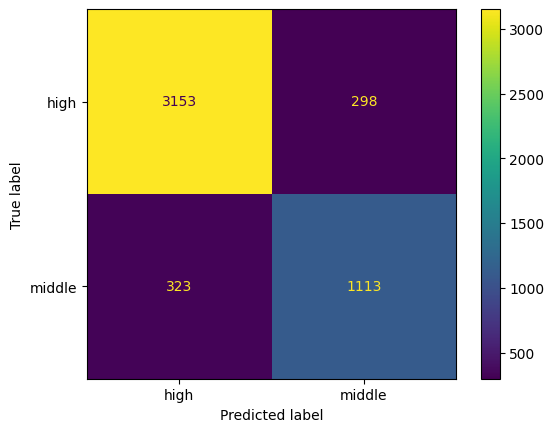

              precision    recall  f1-score   support

        high       0.91      0.91      0.91      3451
      middle       0.79      0.78      0.78      1436

    accuracy                           0.87      4887
   macro avg       0.85      0.84      0.85      4887
weighted avg       0.87      0.87      0.87      4887



In [ ]:
print(f'Best C: {best_C}')
print(f'Best accuracy: {best_accuracy}')

disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(best_report)

Let's see which parameters have had their coefficients turned to 0 due to $l-1$ regularization:

In [ ]:
# extract the parameters found by logisticregression
parameters = best_model.coef_
zeros_mask = parameters == 0
zeros_mask = zeros_mask.reshape(-1)[3:]

# print the corresponding word found in the vocab
vocab = vectorizer.get_feature_names_out()
print(f'first three coeffs:\nunique_word_count = {parameters[0,0]}\navg_sentence_lenght = {parameters[0, 1]}\ntext_lenght = {parameters[0, 2]}')
Top_3_params = np.argsort(np.abs(parameters[0, 3:]))[-3:]
top_3_words = [vocab[i] for i in Top_3_params]
print(f'Top 3 words: {top_3_words[0]}->{parameters[0, 3 + Top_3_params[0]]}, {top_3_words[1]}->{parameters[0, 3 + Top_3_params[1]]}, {top_3_words[2]}->{parameters[0, 3 + Top_3_params[2]]}')
print(f'Vocab size: {len(vocab)}\nNumber of parameters set to 0: {np.sum(zeros_mask)}\n')
print('Some of them:')
for i in range(0, len(vocab), 100):
    if zeros_mask[i]:
        print(vocab[i])

first three coeffs:
unique_word_count = -0.929129889329071
avg_sentence_lenght = -0.08031624132197347
text_lenght = -0.010442258742023768
Top 3 words: opportunity->-0.670406491106752, roles->0.6932698609445369, netspeak->0.7538946671975171
Vocab size: 15727
Number of parameters set to 0: 15003

Some of them:
aa
ache
admiral
alibaba
anders
ape
argue
assets
auckland
bach
bard
beating
benefited
birth
boast
bounced
briefing
buick
cabinets
candidate
carrot
celtic
charmed
chimpanzee
civilization
closely
collectively
communicating
conclude
constant
convinced
count
crick
curing
darker
decreases
dentistry
determining
dime
disguise
doctoral
doyle
ducks
eco
electrician
enabling
entrepreneurs
euros
exist
extraordinary
farmers
fern
firebird
flour
fresher
generals
gliding
graham
groceries
haircut
hardened
heartily
hide
hottest
hurry
imaging
increasingly
inner
intends
investor
jodie
kahlo
kinder
ladders
lawrence
les
lilliput
locations
lucas
maintains
mariam
maturity
members
microphone
mirrored
monk
m

As we can see, only roughly 700 words are really useful for classifying the dataset, and the most important are:
* opportunity
* roles
* netspeak

Let's now test our model on the test set:

Accuracy: 0.8715038508309688


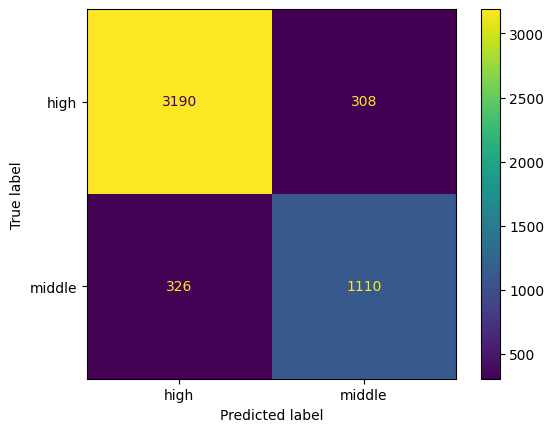

              precision    recall  f1-score   support

        high       0.91      0.91      0.91      3498
      middle       0.78      0.77      0.78      1436

    accuracy                           0.87      4934
   macro avg       0.85      0.84      0.84      4934
weighted avg       0.87      0.87      0.87      4934



In [ ]:
predictions = best_model.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))

We obtain:
* overall accuracy: $87,15\%$
* *high* class f1-score: $91\%$
* *middle* class f1-score: $78\%$

These are good results, unfortunately the model mispredicts a lot of middle school articles. This is probably happening because of the unbalanced dataset, since the number of high school articles is roughly three times the one of middle school articles.

## Support Vector Machine (SVM)

Support Vector Machines (SVMs) are powerful supervised learning algorithms used for both classification and regression tasks. They are particularly well-suited for handling high-dimensional data and complex relationships between features. SVMs operate by finding an optimal hyperplane that maximally separates data points belonging to different classes.

We will use the scikit-learn implementation of the method.

We will use our validation set to address the same problem as before, so finding the best regularization parameter **C**. As before, we will use the $l-1$ regularization.

  0%|          | 0/7 [00:00<?, ?it/s]

=================================== C=0.001: 
Accuracy: 0.8446899938612645



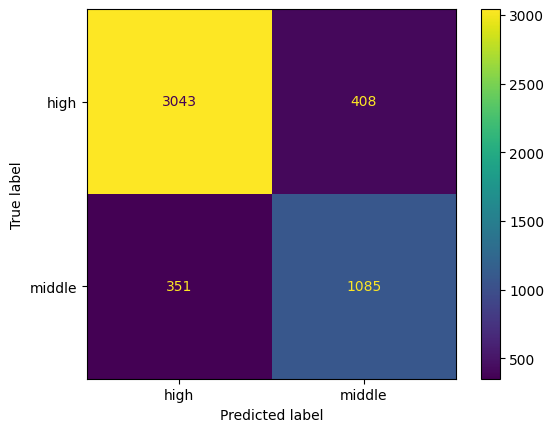

              precision    recall  f1-score   support

        high       0.90      0.88      0.89      3451
      middle       0.73      0.76      0.74      1436

    accuracy                           0.84      4887
   macro avg       0.81      0.82      0.81      4887
weighted avg       0.85      0.84      0.85      4887




=================================== C=0.01: 
Accuracy: 0.8608553304685901



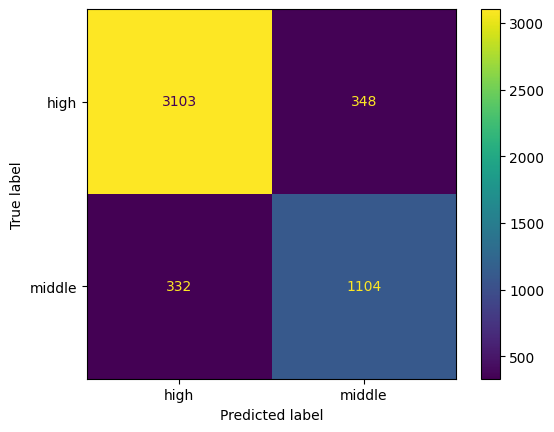

              precision    recall  f1-score   support

        high       0.90      0.90      0.90      3451
      middle       0.76      0.77      0.76      1436

    accuracy                           0.86      4887
   macro avg       0.83      0.83      0.83      4887
weighted avg       0.86      0.86      0.86      4887






/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=================================== C=0.1: 
Accuracy: 0.8710865561694291



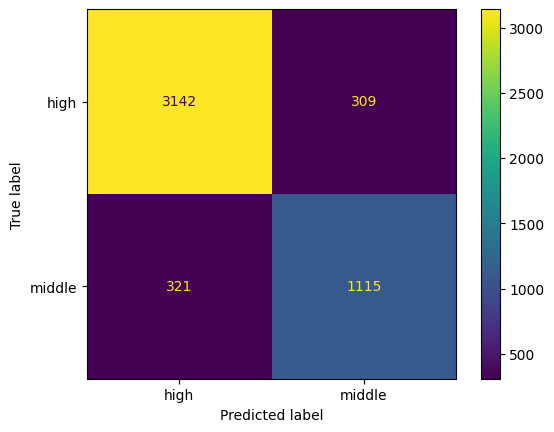

              precision    recall  f1-score   support

        high       0.91      0.91      0.91      3451
      middle       0.78      0.78      0.78      1436

    accuracy                           0.87      4887
   macro avg       0.85      0.84      0.84      4887
weighted avg       0.87      0.87      0.87      4887






/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=================================== C=1: 
Accuracy: 0.8514426028238183



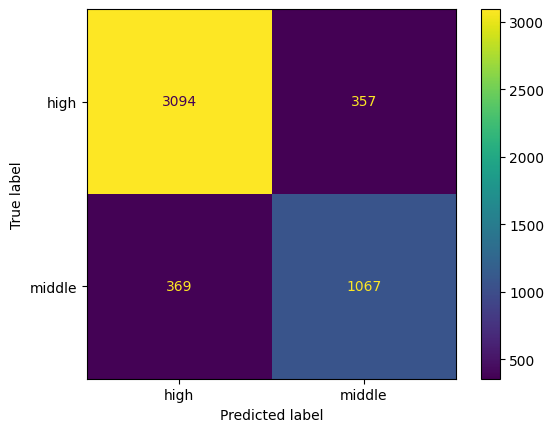

              precision    recall  f1-score   support

        high       0.89      0.90      0.89      3451
      middle       0.75      0.74      0.75      1436

    accuracy                           0.85      4887
   macro avg       0.82      0.82      0.82      4887
weighted avg       0.85      0.85      0.85      4887






/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=================================== C=10: 
Accuracy: 0.8373235113566605



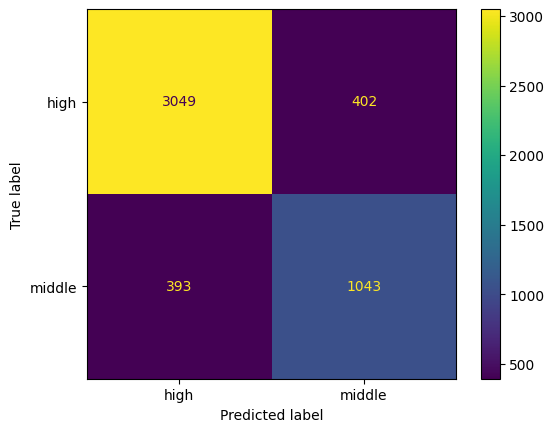

              precision    recall  f1-score   support

        high       0.89      0.88      0.88      3451
      middle       0.72      0.73      0.72      1436

    accuracy                           0.84      4887
   macro avg       0.80      0.80      0.80      4887
weighted avg       0.84      0.84      0.84      4887






/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=================================== C=100: 
Accuracy: 0.8262737875997545



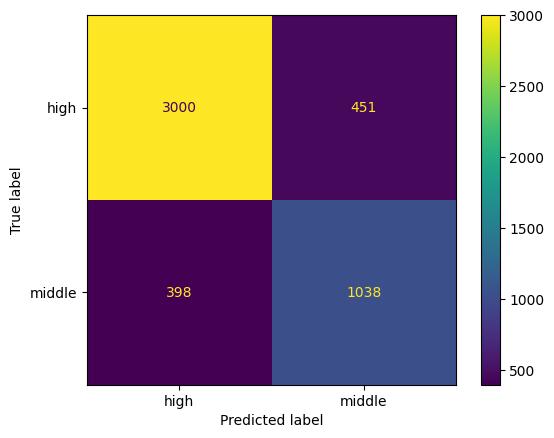

              precision    recall  f1-score   support

        high       0.88      0.87      0.88      3451
      middle       0.70      0.72      0.71      1436

    accuracy                           0.83      4887
   macro avg       0.79      0.80      0.79      4887
weighted avg       0.83      0.83      0.83      4887






/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=================================== C=1000: 
Accuracy: 0.8258645385717209



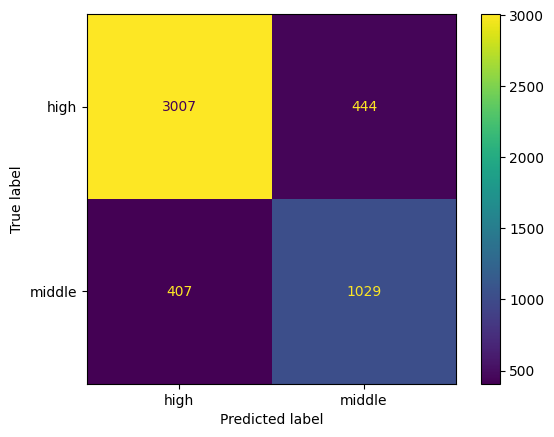

              precision    recall  f1-score   support

        high       0.88      0.87      0.88      3451
      middle       0.70      0.72      0.71      1436

    accuracy                           0.83      4887
   macro avg       0.79      0.79      0.79      4887
weighted avg       0.83      0.83      0.83      4887




Best C: 0.1
Best accuracy: 0.8710865561694291


In [ ]:
from sklearn.svm import LinearSVC

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_model = None
best_accuracy = 0
best_C = None
best_confusion = None
best_report = None

for C in tqdm(C_values):
    model = LinearSVC(C=C, penalty = 'l1').fit(train_x, articles_y)
    transformed_validation = model.predict(val_x)
    accuracy = accuracy_score(validation_y, transformed_validation)
    print(f'=================================== C={C}: \nAccuracy: {accuracy}\n')
    cm = confusion_matrix(validation_y, transformed_validation, labels=['high', 'middle'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
    disp.plot()
    plt.show()
    print(classification_report(validation_y, transformed_validation))
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_C = C
        best_confusion = cm
        best_report = classification_report(validation_y, transformed_validation)
    print('\n\n')

print(f'Best C: {best_C}')
print(f'Best accuracy: {best_accuracy}')

Let's take a look at the information the best model gives us:

Best C: 0.1
Best accuracy: 0.8710865561694291


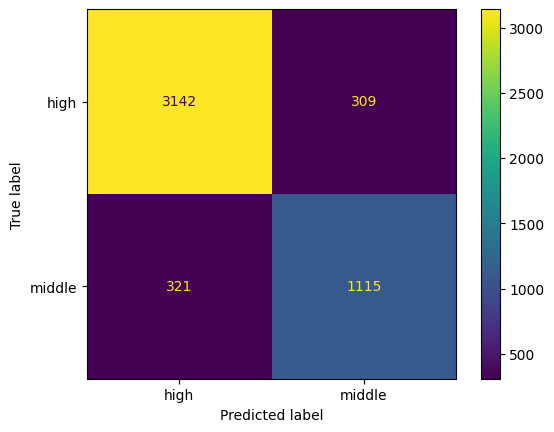

              precision    recall  f1-score   support

        high       0.91      0.91      0.91      3451
      middle       0.78      0.78      0.78      1436

    accuracy                           0.87      4887
   macro avg       0.85      0.84      0.84      4887
weighted avg       0.87      0.87      0.87      4887



In [ ]:
print(f'Best C: {best_C}')
print(f'Best accuracy: {best_accuracy}')

disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion, display_labels=['high', 'middle'])
disp.plot()
plt.show()
print(best_report)

Let's test it on our test set

Accuracy: 0.8595460072963113


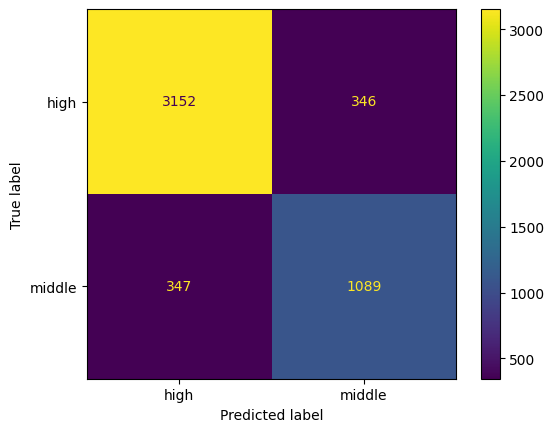

              precision    recall  f1-score   support

        high       0.90      0.90      0.90      3498
      middle       0.76      0.76      0.76      1436

    accuracy                           0.86      4934
   macro avg       0.83      0.83      0.83      4934
weighted avg       0.86      0.86      0.86      4934



In [ ]:
predictions = best_model.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))

We obtain:
* overall accuracy: $86\%$
* *high* class f1-score: $90\%$
* *middle* class f1-score: $76\%$

These are good results, unfortunately the model mispredicts a lot of middle school articles. This is probably happening because of the unbalanced dataset, since the number of high school articles is roughly three times the one of middle school articles.

## Perceptron Classifier

The Perceptron is a foundational algorithm in the field of artificial neural networks, serving as a fundamental building block for more complex architectures. It is a linear classifier that learns a decision boundary by iteratively adjusting its weights based on misclassified examples. Inspired by the biological neuron, the Perceptron takes a set of inputs, applies weights to them, sums the weighted inputs, and then uses an activation function to produce a binary output.

We will use the scikit-learn implementation, which relies on the SDG classifier. The SGDClassifier is a linear classifier in scikit-learn that utilizes Stochastic Gradient Descent (SGD) for training. It's a versatile model capable of performing various classification tasks, including binary classification and multiclass classification.

Among the various possibilities for the loss function, there is the one relying on the perceptron algorithm.

We will try to tweak two parameters using our validation set:
* regularization: $l-1$ or $l-2$ (we also address $l-2$ because the perceptron is more prone to overfitting)
* $α$: the learning rate of the algorithm

In [ ]:
from sklearn.linear_model import SGDClassifier

configurations = [
    {'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.0001},
    {'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.001},
    {'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.01},
    {'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.1},
    {'loss': 'perceptron', 'penalty': 'l1', 'alpha': 1},
    {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 0.0001},
    {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 0.001},
    {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 0.01},
    {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 0.1},
    {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 1},
]

best_model = None
best_accuracy = 0
best_config = None
best_confusion = None
best_report = None

for config in tqdm(configurations):
    sgd_model = SGDClassifier(**config)
    sgd_model.fit(train_x, articles_y)
    predictions_validations = sgd_model.predict(val_x)
    accuracy = accuracy_score(validation_y, predictions_validations)
    print(f'=================================== config={config}: \nAccuracy: {accuracy}\n')
    print(classification_report(validation_y, predictions_validations))

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = sgd_model
        best_config = config
        best_confusion = confusion_matrix(validation_y, predictions_validations, labels=['high', 'middle'])
        best_report = classification_report(validation_y, predictions_validations)

    print('\n\n')

print(f'Best config: {best_config}')
print(f'Best accuracy: {best_accuracy}')

  0%|          | 0/10 [00:00<?, ?it/s]

=================================== config={'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.0001}: 
Accuracy: 0.8385512584407612

              precision    recall  f1-score   support

        high       0.86      0.92      0.89      3451
      middle       0.77      0.64      0.70      1436

    accuracy                           0.84      4887
   macro avg       0.82      0.78      0.80      4887
weighted avg       0.83      0.84      0.83      4887




=================================== config={'loss': 'perceptron', 'penalty': 'l1', 'alpha': 0.001}: 
Accuracy: 0.8240229179455699

              precision    recall  f1-score   support

        high       0.86      0.90      0.88      3451
      middle       0.72      0.65      0.68      1436

    accuracy                           0.82      4887
   macro avg       0.79      0.77      0.78      4887
weighted avg       0.82      0.82      0.82      4887




=================================== config={'loss': 'perceptron', 'penalty': 

Let's take a look at the information the best model gives us:

Best config: {'loss': 'perceptron', 'penalty': 'l2', 'alpha': 0.0001}
Best accuracy: 0.8635154491508082


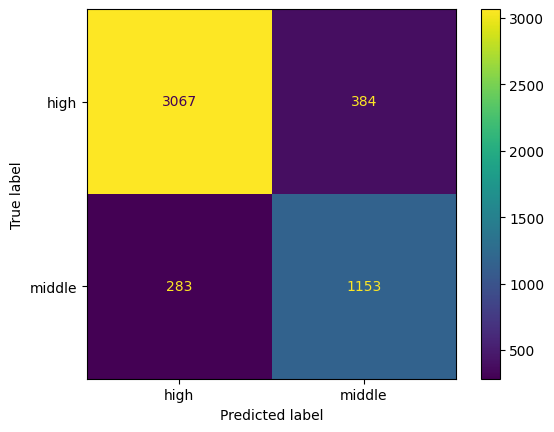

              precision    recall  f1-score   support

        high       0.92      0.89      0.90      3451
      middle       0.75      0.80      0.78      1436

    accuracy                           0.86      4887
   macro avg       0.83      0.85      0.84      4887
weighted avg       0.87      0.86      0.86      4887



In [ ]:
print(f'Best config: {best_config}')
print(f'Best accuracy: {best_accuracy}')

disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion, display_labels=['high', 'middle'])
disp.plot()
plt.show()
print(best_report)

Let's test it on out test set

Accuracy: 0.8552898256992298


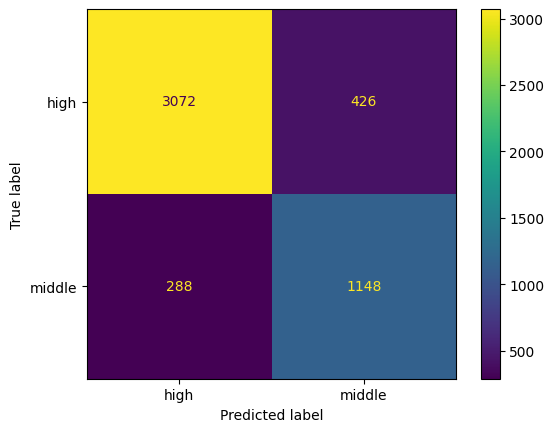

              precision    recall  f1-score   support

        high       0.91      0.88      0.90      3498
      middle       0.73      0.80      0.76      1436

    accuracy                           0.86      4934
   macro avg       0.82      0.84      0.83      4934
weighted avg       0.86      0.86      0.86      4934



In [ ]:
predictions = best_model.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))

We obtain:
* overall accuracy: $85, 5\%$
* *high* class f1-score: $90\%$
* *middle* class f1-score: $76\%$

## Conclusions

Let's take a look at the results of our classifiers:

|model|overall accuracy|*high* class f1-score|*middle* class f1-score|parameters|
|---|---|---|---|---|
|Multinomial Naive Bayes|$83,2\%$|$88\%$|$74\%$|$α: 10$|
|Complementary Naive Bayes|$83\%$|$87\%$|$73\%$|$α: 10$|
|Logistic Regression|$87,15\%$|$91\%$|$78\%$|**C**$: 0.1$|
|Support Vector Machine|$86\%$|$90\%$|$76\%$|**C**$: 0.1$|
|Perceptron|$85,5\%$|$90\%$|$76\%$|**penalty**$: l-2$, $α: 0.0001$|
|**BEST MODEL**|**Logistic Regression**|**Logistic Regression**|**Logistic Regression**||

The majority of the models seem pretty close one to another.
Unfortunately, no model seems to address the problem of the unbalancement of the dataset. Only the Logistic Regression seems to address this problem a bit better, but not much.

In general, the best model overall seems to be:

$$\text{Logistic Regression}$$

The results are:
* **overall accuracy**: $87,15\%$
* ***high*** **class f1-score**: $91\%$
* ***middle*** **class f1-score**: $78\%$

Accuracy: 0.8719092014592622


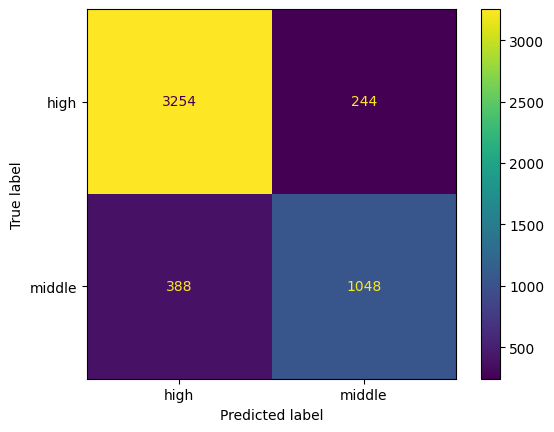

              precision    recall  f1-score   support

        high       0.89      0.93      0.91      3498
      middle       0.81      0.73      0.77      1436

    accuracy                           0.87      4934
   macro avg       0.85      0.83      0.84      4934
weighted avg       0.87      0.87      0.87      4934



In [ ]:
best_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1).fit(train_x, articles_y)
predictions = best_model.predict(test_x)
accuracy = accuracy_score(testing_y, predictions)
print(f'Accuracy: {accuracy}')

cm = confusion_matrix(testing_y, predictions, labels=['high', 'middle'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['high', 'middle'])
disp.plot()
plt.show()

print(classification_report(testing_y, predictions))